# MNIST Multiclass Predictive Pipeline

## End-to-End Classification, Benchmarking, and Robustness Analysis

This project develops an end-to-end multiclass machine learning pipeline for handwritten digit classification using the MNIST (`mnist_784`) dataset.

The project covers:

1. Dataset loading and exploratory data analysis (EDA)
2. Stratified train, validation, and test splitting
3. Pixel normalization and preprocessing
4. Training and hyperparameter comparison of three different classifiers
5. Independent test-set evaluation
6. Comparative performance analysis
7. Class masking and out-of-distribution (OOD) evaluation
8. Inference on personally handwritten digits
9. Analysis of model limitations, robustness, and computational cost

The objective is not only to obtain high classification accuracy, but also to understand how different machine learning approaches behave under standard and challenging conditions.

# MNIST Multiclass Predictive Pipeline

## 0. Environment and Reproducibility

Before beginning the MNIST analysis, the computational environment is verified to ensure that the notebook is running with the intended Python interpreter and that all required libraries are available.

This project uses a dedicated Conda environment named `mnist-pipeline`. The environment contains the libraries required for data manipulation, visualization, classical machine learning, image processing, and neural-network development.

Because one of the benchmark models will be implemented using TensorFlow/Keras, TensorFlow and the available hardware devices are also verified at this stage.

The purpose of this section is reproducibility and troubleshooting. It does not constitute part of the predictive modeling experiment itself.

### 0.1 Environment Check

In [26]:
import sys
import platform
import numpy as np
import pandas as pd
import sklearn
import matplotlib
import seaborn as sns
from PIL import Image
import tensorflow as tf

print("===== SYSTEM =====")
print("Architecture:", platform.machine())

print("\n===== PYTHON =====")
print("Python executable:")
print(sys.executable)

print("\nPython version:")
print(sys.version)

print("\n===== CORE LIBRARIES =====")
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Scikit-learn:", sklearn.__version__)
print("Matplotlib:", matplotlib.__version__)
print("Seaborn:", sns.__version__)
print("Pillow:", Image.__version__)

print("\n===== TENSORFLOW =====")
print("TensorFlow:", tf.__version__)
print("Keras:", tf.keras.__version__)

print("\nAvailable devices:")
for device in tf.config.list_physical_devices():
    print(device)

===== SYSTEM =====
Architecture: arm64

===== PYTHON =====
Python executable:
/opt/miniconda3/envs/mnist-pipeline/bin/python

Python version:
3.12.14 | packaged by Anaconda, Inc. | (main, Aug 27 2026, 14:38:15) [Clang 20.1.8 ]

===== CORE LIBRARIES =====
NumPy: 2.0.2
Pandas: 3.0.5
Scikit-learn: 1.9.0
Matplotlib: 3.11.1
Seaborn: 0.13.2
Pillow: 12.3.0

===== TENSORFLOW =====
TensorFlow: 2.18.1
Keras: 3.15.1

Available devices:
PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')
PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


### Environment Check — Interpretation

The notebook is running in the dedicated `mnist-pipeline` Conda environment, with the required libraries successfully installed. TensorFlow/Keras is also available, and the Apple Silicon GPU is detected through the Metal backend.

The environment is ready for the MNIST experiments.

### 0.2 TensorFlow Smoke Test

In [27]:
# TensorFlow Smoke Test
# This small experiment verifies that TensorFlow can create,
# compile, and train a neural network in the project environment.

import tensorflow as tf
import numpy as np

print("===== TENSORFLOW SMOKE TEST =====")
print("TensorFlow version:", tf.__version__)
print("Keras version:", tf.keras.__version__)

print("\nAvailable devices:")
for device in tf.config.list_physical_devices():
    print(device)

# Create a small synthetic binary-classification dataset.
X = np.random.rand(1000, 20).astype(np.float32)
y = np.random.randint(0, 2, size=1000)

print("\nSynthetic dataset:")
print("X shape:", X.shape)
print("y shape:", y.shape)

# Create a small neural network.
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(20,)),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(2, activation="softmax")
])

# Configure the training process.
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("\nTraining test model...")

history = model.fit(
    X,
    y,
    epochs=2,
    batch_size=32,
    verbose=1
)

print("\n===== SMOKE TEST COMPLETED =====")
print(
    f"Final training accuracy: "
    f"{history.history['accuracy'][-1]:.4f}"
)
print("TensorFlow neural-network training is working.")

===== TENSORFLOW SMOKE TEST =====
TensorFlow version: 2.18.1
Keras version: 3.15.1

Available devices:
PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')
PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')

Synthetic dataset:
X shape: (1000, 20)
y shape: (1000,)

Training test model...
Epoch 1/2


2026-09-09 16:15:23.026255: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M5
2026-09-09 16:15:23.026284: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 32.00 GB
2026-09-09 16:15:23.026288: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 12.48 GB
I0000 00:00:1788963323.026521  108213 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1788963323.026654  108213 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2026-09-09 16:15:23.311535: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4950 - loss: 0.7222
Epoch 2/2
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4870 - loss: 0.7108

===== SMOKE TEST COMPLETED =====
Final training accuracy: 0.4870
TensorFlow neural-network training is working.


### TensorFlow Smoke Test — Interpretation

The smoke test completed successfully, confirming that TensorFlow/Keras can train a neural network in the project environment and that GPU acceleration is available.

The synthetic dataset is used only to verify the installation; its accuracy is not relevant to the MNIST experiment.

We can now proceed to the actual dataset.

# Phase 1 — Loading and Exploratory Data Analysis (EDA)

The MNIST dataset contains 70,000 grayscale images of handwritten digits from 0 to 9. Each image has dimensions of 28 × 28 pixels.

For this project, the dataset will be represented as a matrix where each image is flattened into 784 numerical features (28 × 28). The target variable contains the corresponding digit labels.


The first step is to load the MNIST dataset and understand its structure before applying any preprocessing or training models.

This phase investigates the structure, dimensions, class distribution, pixel values, and visual representation of the dataset before preprocessing and model training.

### 1.1 Load the MNIST Dataset

MNIST is loaded with `fetch_openml()` from scikit-learn, which provides direct access to the `mnist_784` dataset and returns the images as numerical arrays that can be used directly with scikit-learn models.

The target labels are converted from strings to integers because the classification models will use the digit values (0–9) as the target classes.

In [28]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml

print("Loading the MNIST dataset...")

mnist = fetch_openml(
    "mnist_784",
    version=1,
    as_frame=False,
    parser="auto"
)

X = mnist.data
y = mnist.target.astype(np.uint8)

print("MNIST dataset loaded successfully.")

Loading the MNIST dataset...
MNIST dataset loaded successfully.


### 1.2 Dataset Structure

The next step is to verify the dimensions of the feature matrix and target vector and identify the available classes.

For MNIST, each observation should contain 784 features because each original image has 28 × 28 pixels. The target should contain one label for each image.

In [29]:
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nNumber of samples:", X.shape[0])
print("Number of features:", X.shape[1])

print("\nUnique classes:", np.unique(y))
print("Number of classes:", len(np.unique(y)))

X shape: (70000, 784)
y shape: (70000,)

Number of samples: 70000
Number of features: 784

Unique classes: [0 1 2 3 4 5 6 7 8 9]
Number of classes: 10


### 1.2 Dataset Structure — Interpretation

The dataset contains 70,000 images represented by 784 numerical features each. The 784 features correspond to the 28 × 28 pixels of each original image after flattening the two-dimensional image into a one-dimensional vector.

There are 10 target classes, representing the digits 0 through 9, with one label for each image.

The dataset structure is therefore suitable for the multiclass classification pipeline. The next step is to check whether the digit classes are reasonably balanced.

### 1.3 Class Distribution

Before training the models, we need to check how many observations are available for each digit. This helps determine whether the dataset is reasonably balanced or whether some classes are substantially underrepresented.

In [30]:
class_counts = pd.Series(y).value_counts().sort_index()

print("Number of samples per class:")
print(class_counts)

print("\nClass proportions:")
print((class_counts / len(y)).round(4))

Number of samples per class:
0    6903
1    7877
2    6990
3    7141
4    6824
5    6313
6    6876
7    7293
8    6825
9    6958
Name: count, dtype: int64

Class proportions:
0    0.0986
1    0.1125
2    0.0999
3    0.1020
4    0.0975
5    0.0902
6    0.0982
7    0.1042
8    0.0975
9    0.0994
Name: count, dtype: float64


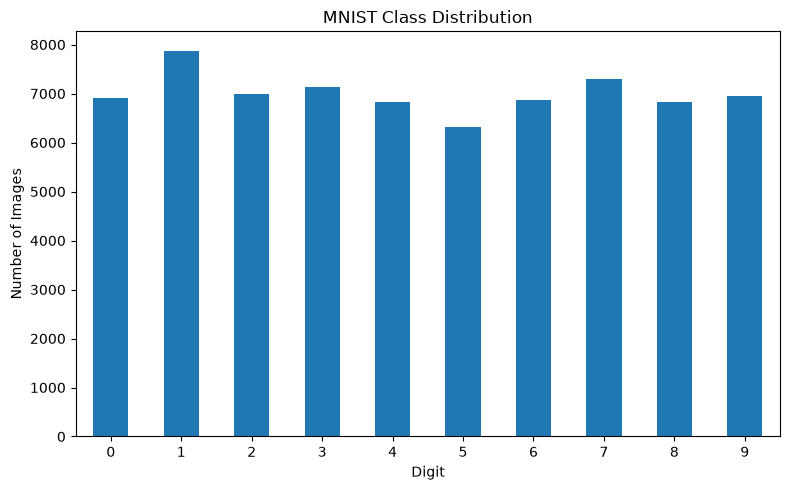

In [31]:
plt.figure(figsize=(8, 5))

class_counts.plot(kind="bar")

plt.title("MNIST Class Distribution")
plt.xlabel("Digit")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### 1.3 Class Distribution — Interpretation

The 10 classes are reasonably balanced, with each digit representing approximately 9% to 11% of the dataset. Digit 5 has the fewest observations (9.02%), while digit 1 has the most (11.25%).

There is therefore no severe class imbalance that would be expected to strongly bias the classifiers toward a particular digit. Nevertheless, stratification will be used when splitting the data so that the class proportions are preserved across the different subsets.

### 1.4 Visualizing the Handwritten Digits

Although the images are stored as vectors with 784 features, each observation originally represents a 28 × 28 grayscale image.

To visualize the digits, the 784 values are reshaped back into a 28 × 28 matrix. The following grid displays 10 examples together with their original labels.

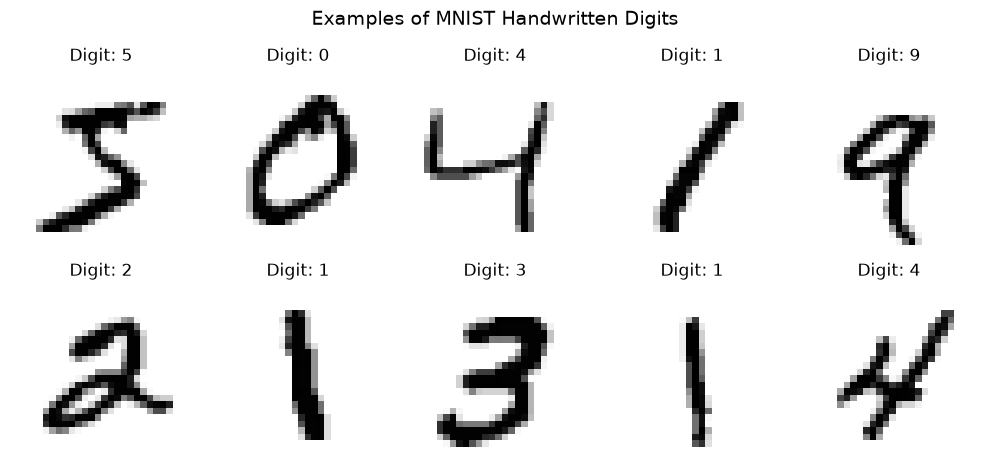

In [32]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.flat):
    ax.imshow(X[i].reshape(28, 28), cmap="binary")
    ax.set_title(f"Digit: {y[i]}")
    ax.axis("off")

plt.suptitle("Examples of MNIST Handwritten Digits", fontsize=14)
plt.tight_layout()
plt.show()

### 1.4 Image Representation — Interpretation

Each MNIST image has 28 × 28 pixels and is stored as a vector of 784 numerical features. Each feature represents the intensity of one pixel, with values ranging from 0 to 255.

A value close to 0 represents a very dark pixel, while a value close to 255 represents a very bright pixel. The `reshape(28, 28)` operation does not change the data; it only converts the 784-element vector back into its original two-dimensional image representation.

For the classical machine learning models used later in this project, the 784-pixel representation can be used directly as numerical input. The MLP models will also receive these 784 features as input, although the neural network can learn nonlinear relationships between them.

## Phase 2 — Data Splitting and Preprocessing

Before training the models, the dataset must be divided into independent training, validation, and test sets.

A stratified split will be used so that the proportion of the ten digit classes remains approximately consistent across all subsets. The test set will remain separate and will only be used for the final model evaluation.

The pixel intensities will then be normalized from their original range of 0–255 to the range 0–1. This provides a consistent numerical scale for the models while preserving the relative intensity information of the images.


### 2.1 Train, Validation, and Test Split

The dataset will be divided into 70% training data, 10% validation data, and 20% test data.

Stratification is applied during both splits to preserve the original class distribution in each subset.


In [33]:
from sklearn.model_selection import train_test_split

# First split: 80% temporary training/validation data and 20% test data
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Temporary training/validation set:", X_train_val.shape)
print("Test set:", X_test.shape)
print("Temporary training/validation labels:", y_train_val.shape)
print("Test labels:", y_test.shape)

Temporary training/validation set: (56000, 784)
Test set: (14000, 784)
Temporary training/validation labels: (56000,)
Test labels: (14000,)


### 2.2 Training and Validation Split

The temporary training/validation set is divided again into 49,000 training images and 7,000 validation images.

The validation set will be used during model development and hyperparameter selection, while the independent test set will remain untouched until the final evaluation.


In [34]:
# Second split: 70% training and 10% validation of the original dataset
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.125,
    random_state=42,
    stratify=y_train_val
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

print("\nTraining labels:", y_train.shape)
print("Validation labels:", y_val.shape)
print("Test labels:", y_test.shape)

Training set: (49000, 784)
Validation set: (7000, 784)
Test set: (14000, 784)

Training labels: (49000,)
Validation labels: (7000,)
Test labels: (14000,)


### 2.3 Verifying Stratification

The class proportions are compared across the training, validation, and test sets to confirm that stratification preserved a similar distribution of the ten digit classes.


In [35]:
split_distribution = pd.DataFrame({
    "Training": pd.Series(y_train).value_counts(normalize=True),
    "Validation": pd.Series(y_val).value_counts(normalize=True),
    "Test": pd.Series(y_test).value_counts(normalize=True)
}).sort_index()

split_distribution.round(4)

,Training,Validation,Test
0,0.0986,0.0986,0.0986
1,0.1125,0.1126,0.1125
2,0.0999,0.0999,0.0999
3,0.1020,0.1020,0.1020
4,0.0975,0.0974,0.0975
5,0.0902,0.0901,0.0902
6,0.0982,0.0983,0.0982
7,0.1042,0.1041,0.1042
8,0.0975,0.0976,0.0975
9,0.0994,0.0994,0.0994


### 2.3 Stratification — Interpretation

The class proportions are highly consistent across the training, validation, and test sets. The small differences are due only to the discrete number of samples in each subset.

This confirms that stratification successfully preserved the original MNIST class distribution and reduces the risk of introducing sampling bias through the data split.


### 2.4 Pixel Normalization

The original MNIST pixel intensities range from 0 to 255. They will be converted to floating-point values in the range 0 to 1 by dividing each pixel value by 255.

The normalized datasets will be used for model training and evaluation, while the original data will be preserved for visualization and other preprocessing steps.


In [36]:
# Normalize pixel intensities from [0, 255] to [0, 1]
X_train_scaled = X_train.astype("float32") / 255.0
X_val_scaled = X_val.astype("float32") / 255.0
X_test_scaled = X_test.astype("float32") / 255.0

print("Training pixel range:", X_train_scaled.min(), "to", X_train_scaled.max())
print("Validation pixel range:", X_val_scaled.min(), "to", X_val_scaled.max())
print("Test pixel range:", X_test_scaled.min(), "to", X_test_scaled.max())

Training pixel range: 0.0 to 1.0
Validation pixel range: 0.0 to 1.0
Test pixel range: 0.0 to 1.0


In [37]:
print("Training shape:", X_train_scaled.shape)
print("Validation shape:", X_val_scaled.shape)
print("Test shape:", X_test_scaled.shape)

print("\nTraining dtype:", X_train_scaled.dtype)
print("Validation dtype:", X_val_scaled.dtype)
print("Test dtype:", X_test_scaled.dtype)

Training shape: (49000, 784)
Validation shape: (7000, 784)
Test shape: (14000, 784)

Training dtype: float32
Validation dtype: float32
Test dtype: float32


### Phase 2 — Interpretation

The dataset was divided into 49,000 training images, 7,000 validation images, and 14,000 test images, corresponding to 70%, 10%, and 20% of the original dataset.

Stratification was applied during both splitting steps, preserving the original class distribution across the three subsets.

The pixel intensities were converted from integers in the range 0–255 to `float32` values between 0 and 1. This normalization provides a consistent numerical scale for the models and is particularly important for distance-based models such as KNN and for gradient-based neural network models.

The final shapes and data types confirm that preprocessing did not change the number of features or observations. The test set remains completely independent and will only be used for the final model evaluation in Phase 4.


## Phase 3 — Model Training and Hyperparameter Tuning

Three distinct classification approaches will be developed and compared in this phase:

1. K-Nearest Neighbors (KNN), a distance-based classical machine learning algorithm.
2. Scikit-learn MLPClassifier, a multilayer perceptron neural network.
3. TensorFlow/Keras MLP, a neural network implemented with a deep learning framework.

For each model, at least two hyperparameters will be evaluated using the training and validation sets. The independent test set will remain untouched until Phase 4.

Model performance will be evaluated using validation accuracy during development, while training and prediction time will also be recorded to support the computational cost comparison in the final analysis.


### 3.1 Model 1 — K-Nearest Neighbors (KNN)

K-Nearest Neighbors (KNN) is used as the first predictive model because it provides a simple and interpretable classical machine learning baseline for multiclass image classification.

KNN classifies an observation according to the labels of its nearest observations in the feature space. In this project, each MNIST image is represented by 784 normalized pixel features. The model therefore operates directly on the pixel-level representation without explicitly learning spatial structures or higher-level image features.

KNN is particularly useful as a baseline because it has very little model-fitting complexity. However, this simplicity comes with an important computational trade-off: most of the computational work occurs during prediction because the algorithm must calculate distances between new observations and stored training observations.

KNN provides a useful classical machine learning baseline for this project because it approaches the classification problem differently from the two neural-network models used later.

#### KNN Default Configuration

Before tuning any hyperparameters, we establish a baseline using the standard default configuration of `KNeighborsClassifier`.

The main parameters relevant to this experiment are:

* `n_neighbors=5`: the classifier considers the five nearest training observations when predicting a class.
* `weights="uniform"`: each of the five neighbors contributes equally to the prediction.
* `metric="minkowski"`: the default distance metric.
* `p=2`: with the Minkowski metric, this corresponds to Euclidean distance.
* `algorithm="auto"`: scikit-learn automatically selects an appropriate nearest-neighbor search algorithm.
* `n_jobs=None`: computation uses the default job configuration.

For this project, we will keep the distance metric, search algorithm, and other parameters at their defaults. We will first evaluate this default configuration as a baseline and then tune two parameters: `n_neighbors` and `weights`.

This provides a clear comparison between the untuned default model and the selected tuned model.


In [38]:
# Import the KNN classifier and the accuracy metric.
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import pandas as pd
import time

# Create the baseline KNN model using scikit-learn's default parameters.
knn_default = KNeighborsClassifier()

# Measure the time required to fit the model.
knn_default_start = time.perf_counter()
knn_default.fit(X_train_scaled, y_train)
knn_default_fit_time = time.perf_counter() - knn_default_start

# Measure the time required to generate validation predictions.
knn_default_pred_start = time.perf_counter()
y_val_pred_knn_default = knn_default.predict(X_val_scaled)
knn_default_prediction_time = time.perf_counter() - knn_default_pred_start

# Calculate validation accuracy for the default model.
knn_default_accuracy = accuracy_score(y_val, y_val_pred_knn_default)

print("KNN baseline (default parameters)")
print(f"n_neighbors: {knn_default.n_neighbors}")
print(f"weights: {knn_default.weights}")
print(f"metric: {knn_default.metric}")
print(f"p: {knn_default.p}")
print(f"Validation accuracy: {knn_default_accuracy:.4f}")
print(f"Fit time: {knn_default_fit_time:.4f} seconds")
print(f"Validation prediction time: {knn_default_prediction_time:.4f} seconds")

KNN baseline (default parameters)
n_neighbors: 5
weights: uniform
metric: minkowski
p: 2
Validation accuracy: 0.9694
Fit time: 0.0067 seconds
Validation prediction time: 1.2568 seconds


#### KNN Hyperparameter Tuning

After establishing the default baseline, two hyperparameters will be tuned: `n_neighbors` and `weights`.

`n_neighbors` determines how many nearby training observations are considered when assigning a class.

* Smaller values make the classifier more sensitive to local patterns. This can capture fine-grained differences between handwritten digits, but it can also make predictions more sensitive to noise or unusual observations.
* Larger values use a broader neighborhood and therefore produce smoother decisions. This can reduce sensitivity to individual observations, but excessive smoothing may remove useful local structure.

The second parameter, `weights`, determines how the neighbors contribute to the prediction.

* `uniform`: all selected neighbors contribute equally, regardless of their distance from the observation being classified.
* `distance`: closer neighbors receive greater influence than more distant neighbors.

These parameters are particularly relevant to MNIST because visually similar handwritten digits may form local clusters in the feature space. The experiment will therefore investigate whether using a smaller or larger neighborhood and whether weighting neighbors by distance improves validation performance.

The following candidate values will be tested:

* `n_neighbors`: 3, 5, and 7
* `weights`: `uniform` and `distance`

The value 5 with uniform weighting represents the default configuration and is included in the experiment so that the tuning results can be directly compared with the baseline.

Only the training and validation sets will be used during this experiment. The test set remains untouched until Phase 4.


In [39]:
# Define the KNN hyperparameter configurations to evaluate.
# The default configuration is included as a reference point.
knn_candidates = [
    {"n_neighbors": 3, "weights": "uniform"},
    {"n_neighbors": 3, "weights": "distance"},
    {"n_neighbors": 5, "weights": "uniform"},
    {"n_neighbors": 5, "weights": "distance"},
    {"n_neighbors": 7, "weights": "uniform"},
    {"n_neighbors": 7, "weights": "distance"},
]

print("KNN configurations to evaluate:")
for config in knn_candidates:
    print(config)

KNN configurations to evaluate:
{'n_neighbors': 3, 'weights': 'uniform'}
{'n_neighbors': 3, 'weights': 'distance'}
{'n_neighbors': 5, 'weights': 'uniform'}
{'n_neighbors': 5, 'weights': 'distance'}
{'n_neighbors': 7, 'weights': 'uniform'}
{'n_neighbors': 7, 'weights': 'distance'}


In [40]:
# Evaluate every KNN configuration using the training and validation sets.

knn_results = []

for config in knn_candidates:
    # Create a new KNN model for the current hyperparameter combination.
    model = KNeighborsClassifier(
        n_neighbors=config["n_neighbors"],
        weights=config["weights"]
    )

    # Measure fitting time.
    fit_start = time.perf_counter()
    model.fit(X_train_scaled, y_train)
    fit_time = time.perf_counter() - fit_start

    # Measure validation prediction time.
    prediction_start = time.perf_counter()
    y_val_pred = model.predict(X_val_scaled)
    prediction_time = time.perf_counter() - prediction_start

    # Calculate validation accuracy.
    validation_accuracy = accuracy_score(y_val, y_val_pred)

    # Store the experiment results.
    knn_results.append({
        "n_neighbors": config["n_neighbors"],
        "weights": config["weights"],
        "validation_accuracy": validation_accuracy,
        "fit_time_seconds": fit_time,
        "validation_prediction_time_seconds": prediction_time
    })

# Convert the results into a DataFrame for easier inspection.
knn_results_df = pd.DataFrame(knn_results)

# Sort primarily by validation accuracy.
# For equal accuracy, the faster prediction configuration appears first.
knn_results_df = knn_results_df.sort_values(
    by=["validation_accuracy", "validation_prediction_time_seconds"],
    ascending=[False, True]
).reset_index(drop=True)

print("KNN hyperparameter tuning results:")
display(knn_results_df)

KNN hyperparameter tuning results:


,n_neighbors,weights,validation_accuracy,fit_time_seconds,validation_prediction_time_seconds
0,3,distance,0.972286,0.006916,1.216985
1,3,uniform,0.971857,0.007942,1.229699
2,5,distance,0.971429,0.006967,1.208053
3,7,distance,0.969857,0.006684,1.210532
4,5,uniform,0.969429,0.006678,1.200905
5,7,uniform,0.968429,0.006659,1.216304


### Interpretation

The default KNN configuration (`n_neighbors=5`, `weights="uniform"`) achieved a validation accuracy of **96.94%**.

The best configuration among the tested candidates was `n_neighbors=3` with `weights="distance"`, achieving a validation accuracy of **97.23%**. This represents an improvement of approximately **0.29 percentage points** over the default baseline.

The results show that the smaller neighborhood performed better for the tested values. Distance weighting also consistently improved validation accuracy compared with uniform weighting for the same number of neighbors.

### Technical Meaning

Using three neighbors allows KNN to make more local decisions in the feature space. Distance weighting further emphasizes the closest observations, which may be beneficial when visually similar MNIST images are located close together but more distant neighbors belong to different digit classes.

The improvement over the default configuration is relatively small, so the result should be interpreted as a validation-based improvement within the tested hyperparameter range rather than evidence that this configuration is universally optimal.

The timing results are also consistent with the nature of KNN. Fitting is very fast because the algorithm primarily stores the training observations, whereas prediction is substantially more computationally expensive because nearest neighbors must be identified for each validation observation.

### Decision

The configuration `n_neighbors=3` with `weights="distance"` will be selected as the final KNN configuration for this project because it achieved the highest validation accuracy among the tested candidates.

The test set has not been used. The final KNN model will therefore be evaluated on the independent test set only during Phase 4.


#### Final KNN Model

The validation experiment identified `n_neighbors=3` with `weights="distance"` as the best configuration among the tested candidates.

A final KNN model is now trained using this selected configuration and the complete training set. The validation set is not used for fitting the final model, and the test set remains untouched until Phase 4.

The final model's fitting time is recorded for later comparison with the other models.


In [41]:
# Train the final KNN model using the configuration selected from validation.
knn_model = KNeighborsClassifier(
    n_neighbors=3,
    weights="distance"
)

# Measure final model fitting time.
knn_final_fit_start = time.perf_counter()
knn_model.fit(X_train_scaled, y_train)
knn_final_fit_time = time.perf_counter() - knn_final_fit_start

# Evaluate the final model on the validation set.
knn_validation_pred_start = time.perf_counter()
y_val_pred_knn = knn_model.predict(X_val_scaled)
knn_validation_prediction_time = (
    time.perf_counter() - knn_validation_pred_start
)

knn_validation_accuracy = accuracy_score(y_val, y_val_pred_knn)

# Store the final KNN results for the model comparison in Phase 4.
knn_final_results = {
    "model": "KNN",
    "validation_accuracy": knn_validation_accuracy,
    "fit_time_seconds": knn_final_fit_time,
    "validation_prediction_time_seconds": knn_validation_prediction_time
}

print("Final KNN model")
print(f"n_neighbors: {knn_model.n_neighbors}")
print(f"weights: {knn_model.weights}")
print(f"Validation accuracy: {knn_validation_accuracy:.4f}")
print(f"Final fit time: {knn_final_fit_time:.4f} seconds")
print(
    f"Validation prediction time: "
    f"{knn_validation_prediction_time:.4f} seconds"
)

Final KNN model
n_neighbors: 3
weights: distance
Validation accuracy: 0.9723
Final fit time: 0.0080 seconds
Validation prediction time: 1.2418 seconds


### 3.2 Model 2 — Scikit-learn MLP

The second model is a Multilayer Perceptron (MLP) implemented with scikit-learn's `MLPClassifier`.

An MLP is a feed-forward artificial neural network that learns a set of weights from the training data. The input features are passed through one or more hidden layers, where neurons apply weighted transformations and activation functions. The network then produces an output for the ten MNIST digit classes.

For this project, the MLP provides a useful contrast with KNN. KNN is an instance-based, distance-based method that does not explicitly learn a parametric representation of the data. The MLP instead learns parameters during training and uses those learned parameters to classify new observations.

Although an MLP is a neural network, this implementation is part of scikit-learn's classical machine-learning ecosystem. It therefore provides an intermediate point between KNN and the TensorFlow/Keras neural network that will be evaluated as Model 3.

### Important Default Parameters

The default configuration in the installed scikit-learn environment was inspected directly using `MLPClassifier().get_params()`.

The most important defaults are:

* `hidden_layer_sizes=(100,)`: one hidden layer containing 100 neurons.
* `activation="relu"`: ReLU is used as the hidden-layer activation function.
* `solver="adam"`: Adam is used to optimize the network weights.
* `alpha=0.0001`: L2 regularization is applied to the model weights.
* `learning_rate_init=0.001`: the initial learning rate used by the optimizer.
* `batch_size="auto"`: the batch size is determined automatically.
* `learning_rate="constant"`: the learning-rate schedule remains constant.
* `max_iter=200`: training is allowed to run for up to 200 iterations.
* `tol=0.0001`: training can stop when the optimization improvement becomes sufficiently small.
* `early_stopping=False`: scikit-learn does not automatically reserve part of the training data for early stopping.
* `shuffle=True`: training samples are shuffled during optimization.
* `momentum=0.9`: momentum is used when applicable to the optimizer.
* `beta_1=0.9` and `beta_2=0.999`: default exponential-decay parameters used by Adam.
* `nesterovs_momentum=True`: Nesterov momentum is enabled when the selected solver supports it.

For reproducibility, `random_state=42` is set explicitly. The other model parameters remain at their default values for the baseline.

The default configuration will first be evaluated on the validation set. This establishes a baseline before any hyperparameter tuning is performed.

In [42]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
import pandas as pd
import time

# Inspect the default MLPClassifier parameters in the active environment.

mlp_default = MLPClassifier(random_state=42)

print("Scikit-learn MLPClassifier default parameters")
for parameter, value in mlp_default.get_params().items():
    print(f"{parameter}: {value}")

Scikit-learn MLPClassifier default parameters
activation: relu
alpha: 0.0001
batch_size: auto
beta_1: 0.9
beta_2: 0.999
early_stopping: False
epsilon: 1e-08
hidden_layer_sizes: (100,)
learning_rate: constant
learning_rate_init: 0.001
max_fun: 15000
max_iter: 200
momentum: 0.9
n_iter_no_change: 10
nesterovs_momentum: True
power_t: 0.5
random_state: 42
shuffle: True
solver: adam
tol: 0.0001
validation_fraction: 0.1
verbose: False
warm_start: False


In [43]:
# Establish the MLP baseline using the default model configuration.
mlp_default = MLPClassifier(random_state=42)

# Measure model fitting time.
mlp_default_fit_start = time.perf_counter()
mlp_default.fit(X_train_scaled, y_train)
mlp_default_fit_time = time.perf_counter() - mlp_default_fit_start

# Measure validation prediction time.
mlp_default_pred_start = time.perf_counter()
y_val_pred_mlp_default = mlp_default.predict(X_val_scaled)
mlp_default_validation_prediction_time = (
    time.perf_counter() - mlp_default_pred_start
)

# Calculate validation accuracy.
mlp_default_validation_accuracy = accuracy_score(
    y_val,
    y_val_pred_mlp_default
)

print("Scikit-learn MLP baseline")
print(f"hidden_layer_sizes: {mlp_default.hidden_layer_sizes}")
print(f"activation: {mlp_default.activation}")
print(f"solver: {mlp_default.solver}")
print(f"alpha: {mlp_default.alpha}")
print(f"learning_rate_init: {mlp_default.learning_rate_init}")
print(f"max_iter: {mlp_default.max_iter}")
print(f"Actual iterations: {mlp_default.n_iter_}")
print(f"Validation accuracy: {mlp_default_validation_accuracy:.4f}")
print(f"Fit time: {mlp_default_fit_time:.4f} seconds")
print(
    f"Validation prediction time: "
    f"{mlp_default_validation_prediction_time:.4f} seconds"
)

/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


Scikit-learn MLP baseline
hidden_layer_sizes: (100,)
activation: relu
solver: adam
alpha: 0.0001
learning_rate_init: 0.001
max_iter: 200
Actual iterations: 62
Validation accuracy: 0.9764
Fit time: 8.9182 seconds
Validation prediction time: 0.0061 seconds


/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


### Interpretation

The default scikit-learn MLP achieved a validation accuracy of **97.64%** after 62 training iterations. The model therefore provides a strong baseline before hyperparameter tuning.

The fitting process took approximately **8.46 seconds**, while prediction on the validation set took only **0.008 seconds**. Compared with KNN, the MLP requires substantially more computation during training because it learns the network weights iteratively, but prediction is much faster once the model has been trained.

The model stopped after 62 iterations rather than reaching the maximum of 200 iterations, indicating that the optimization stopping criterion was reached before the maximum iteration budget was exhausted.

The baseline demonstrates the advantage of learning a parametric representation of the MNIST data. Unlike KNN, which stores the training observations and performs neighbor searches during prediction, the MLP learns weights that can be used to classify new observations efficiently.

The baseline accuracy of 97.64% is higher than the selected KNN validation accuracy of 97.23%. However, this comparison is preliminary because the models use different learning mechanisms and the MLP has not yet been tuned.


### Hyperparameter Tuning

Two hyperparameters will be tuned for the scikit-learn MLP: `hidden_layer_sizes` and `alpha`.

`hidden_layer_sizes` controls the size of the hidden layer and therefore the capacity of the network. The experiment will compare 64 and 128 neurons.

`alpha` controls the strength of L2 regularization. The experiment will compare `0.0001` and `0.001`. The default value of `0.0001` is included as a reference, while `0.001` represents stronger regularization.

The following four configurations will be evaluated:

* `(64,)`, `alpha=0.0001`
* `(64,)`, `alpha=0.001`
* `(128,)`, `alpha=0.0001`
* `(128,)`, `alpha=0.001`

All other model parameters will remain fixed at their default values, including ReLU activation, Adam optimization, an initial learning rate of `0.001`, and a maximum of 200 iterations.

Each configuration will be trained using the training set and evaluated using the validation set. The test set will not be used during tuning.

Because each configuration requires a separate neural-network training process, this experiment is expected to require considerably more computation than the KNN tuning experiment.


In [44]:
mlp_candidates = [
    {"hidden_layer_sizes": (64,), "alpha": 0.0001},
    {"hidden_layer_sizes": (64,), "alpha": 0.001},
    {"hidden_layer_sizes": (128,), "alpha": 0.0001},
    {"hidden_layer_sizes": (128,), "alpha": 0.001},
]

mlp_results = []

for config in mlp_candidates:
    model = MLPClassifier(
        hidden_layer_sizes=config["hidden_layer_sizes"],
        alpha=config["alpha"],
        random_state=42
    )

    # Measure training time.
    fit_start = time.perf_counter()
    model.fit(X_train_scaled, y_train)
    fit_time = time.perf_counter() - fit_start

    # Measure validation prediction time.
    prediction_start = time.perf_counter()
    y_val_pred = model.predict(X_val_scaled)
    prediction_time = time.perf_counter() - prediction_start

    # Calculate validation accuracy.
    validation_accuracy = accuracy_score(
        y_val,
        y_val_pred
    )

    mlp_results.append({
        "hidden_layer_sizes": config["hidden_layer_sizes"],
        "alpha": config["alpha"],
        "validation_accuracy": validation_accuracy,
        "fit_time_seconds": fit_time,
        "validation_prediction_time_seconds": prediction_time,
        "n_iter": model.n_iter_
    })

mlp_results_df = pd.DataFrame(mlp_results)

mlp_results_df = mlp_results_df.sort_values(
    by=["validation_accuracy", "validation_prediction_time_seconds"],
    ascending=[False, True]
).reset_index(drop=True)

print("Scikit-learn MLP hyperparameter tuning results:")
display(mlp_results_df)

/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/mnist-pipeline/lib/py

Scikit-learn MLP hyperparameter tuning results:


/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


,hidden_layer_sizes,alpha,validation_accuracy,fit_time_seconds,validation_prediction_time_seconds,n_iter
0,"(128,)",0.0010,0.978143,9.227993,0.002762,58
1,"(128,)",0.0001,0.977429,8.301669,0.002851,51
2,"(64,)",0.0010,0.971143,8.767541,0.002555,89
3,"(64,)",0.0001,0.969143,7.449814,0.002435,76


### Interpretation

The best configuration among the tested candidates was a single hidden layer with **128 neurons** and an L2 regularization strength of **`alpha=0.001`**. It achieved a validation accuracy of **97.81%**.

This represents an improvement of approximately **0.17 percentage points** over the default MLP baseline, which achieved 97.64% validation accuracy.
The results suggest that the default 100-neuron hidden layer was slightly below the most effective capacity among the tested configurations. 

The results also show a consistent effect of the hidden-layer size. The 128-neuron configurations outperformed the corresponding 64-neuron configurations. Increasing `alpha` from 0.0001 to 0.001 also improved validation accuracy for both hidden-layer sizes in this experiment.

The best configuration required approximately **8.97 seconds** for training and **0.003 seconds** for validation prediction.

Increasing the hidden layer to 128 neurons provided additional representational capacity, while the stronger L2 regularization helped control the model weights.

The improvement is relatively small, so the tuning did not fundamentally change the performance of the MLP. It produced a modest improvement over the default configuration.

### Decision

The configuration `hidden_layer_sizes=(128,)` and `alpha=0.001` will be selected as the final scikit-learn MLP configuration because it achieved the highest validation accuracy among the tested candidates.

The test set remains untouched and will only be used during Phase 4 for the final comparison of all three models.


### Final Scikit-learn MLP Model

The validation experiment identified `hidden_layer_sizes=(128,)` with `alpha=0.001` as the best configuration among the tested candidates.

A final scikit-learn MLP model is now trained using this selected configuration and the complete training set. The validation set is not used for fitting the final model, and the test set remains untouched until Phase 4.

The final model's fitting time and validation prediction time are recorded for later comparison with the other models.


In [45]:
# Train the final scikit-learn MLP model using the configuration selected from validation.
mlp_model = MLPClassifier(
    hidden_layer_sizes=(128,),
    alpha=0.001,
    random_state=42
)

# Measure final model fitting time.
mlp_final_fit_start = time.perf_counter()
mlp_model.fit(X_train_scaled, y_train)
mlp_final_fit_time = time.perf_counter() - mlp_final_fit_start

# Evaluate the final model on the validation set.
mlp_validation_pred_start = time.perf_counter()
y_val_pred_mlp = mlp_model.predict(X_val_scaled)
mlp_validation_prediction_time = (
    time.perf_counter() - mlp_validation_pred_start
)

mlp_validation_accuracy = accuracy_score(
    y_val,
    y_val_pred_mlp
)

# Store the final MLP results for the model comparison in Phase 4.
mlp_final_results = {
    "model": "Scikit-learn MLP",
    "validation_accuracy": mlp_validation_accuracy,
    "fit_time_seconds": mlp_final_fit_time,
    "validation_prediction_time_seconds": mlp_validation_prediction_time
}

print("Final Scikit-learn MLP model")
print(f"hidden_layer_sizes: {mlp_model.hidden_layer_sizes}")
print(f"alpha: {mlp_model.alpha}")
print(f"Actual iterations: {mlp_model.n_iter_}")
print(f"Validation accuracy: {mlp_validation_accuracy:.4f}")
print(f"Final fit time: {mlp_final_fit_time:.4f} seconds")
print(
    f"Validation prediction time: "
    f"{mlp_validation_prediction_time:.4f} seconds"
)

/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


Final Scikit-learn MLP model
hidden_layer_sizes: (128,)
alpha: 0.001
Actual iterations: 58
Validation accuracy: 0.9781
Final fit time: 9.1534 seconds
Validation prediction time: 0.0031 seconds


/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


### 3.3 Model 3 — TensorFlow/Keras MLP

The third model is a Multilayer Perceptron (MLP) implemented using TensorFlow and Keras.

Like the scikit-learn MLP, this model is a feed-forward neural network that learns weights from the training data. It provides a second neural-network implementation using a dedicated deep-learning framework, allowing its performance and computational behaviour to be compared with both KNN and the scikit-learn MLP.

For MNIST, the network receives the 784 normalized pixel values as input and uses a fully connected hidden layer with ReLU activation, followed by an output layer with 10 units and softmax activation. The output layer produces a probability distribution across the ten digit classes.

Unlike scikit-learn's `MLPClassifier`, Keras does not define a single universal default architecture for an MLP classifier. Therefore, the baseline architecture and training configuration used in this project are explicitly defined rather than treated as framework defaults.

### Baseline Configuration

The baseline Keras MLP will use the following configuration:

* **Network architecture:** one fully connected hidden layer with 128 neurons, followed by an output layer with 10 neurons.
* **Hidden-layer activation function:** ReLU (`relu`), introducing non-linearity into the network.
* **Output-layer activation function:** softmax (`softmax`), producing a probability distribution across the ten digit classes.
* **Optimizer:** Adam, used to update the network weights during training.
* **Learning rate:** `0.001`, controlling the size of the weight updates made by the optimizer.
* **Loss function:** sparse categorical cross-entropy, appropriate for multiclass classification with integer class labels.
* **Batch size:** 128 training samples per optimization step.
* **Number of epochs:** 10 complete passes through the training data.

The baseline is deliberately kept simple so that it provides a clear reference point for the subsequent hyperparameter experiments.

The model will be trained using the training set and evaluated on the validation set after each epoch. The test set will remain untouched until Phase 4.

For reproducibility, the random seed will be fixed at `42`.



In [46]:
# Set random seeds for reproducibility.
import numpy as np
import tensorflow as tf

tf.keras.utils.set_random_seed(42)


# Build the Keras MLP with configurable hidden-layer size
# and learning rate.
def build_keras_mlp(hidden_units=128, learning_rate=0.001):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(784,)),
        tf.keras.layers.Dense(
            hidden_units,
            activation="relu"
        ),
        tf.keras.layers.Dense(
            10,
            activation="softmax"
        )
    ])

    optimizer = tf.keras.optimizers.Adam(
        learning_rate=learning_rate
    )

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [47]:
# Establish the Keras MLP baseline using the project-defined configuration.
keras_baseline_model = build_keras_mlp(
    hidden_units=128,
    learning_rate=0.001
)

# Measure model fitting time.
keras_baseline_fit_start = time.perf_counter()

keras_baseline_history = keras_baseline_model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=10,
    batch_size=128,
    verbose=1
)

keras_baseline_fit_time = (
    time.perf_counter() - keras_baseline_fit_start
)

# Measure validation prediction time.
keras_baseline_pred_start = time.perf_counter()

y_val_pred_proba_keras_baseline = (
    keras_baseline_model.predict(
        X_val_scaled,
        verbose=0
    )
)

keras_baseline_validation_prediction_time = (
    time.perf_counter() - keras_baseline_pred_start
)

# Convert class probabilities to predicted class labels.
y_val_pred_keras_baseline = np.argmax(
    y_val_pred_proba_keras_baseline,
    axis=1
)

# Calculate validation accuracy.
keras_baseline_validation_accuracy = accuracy_score(
    y_val,
    y_val_pred_keras_baseline
)

print("TensorFlow/Keras MLP baseline")
print("hidden_units: 128")
print("learning_rate: 0.001")
print("batch_size: 128")
print("epochs: 10")
print(
    f"Validation accuracy: "
    f"{keras_baseline_validation_accuracy:.4f}"
)
print(
    f"Fit time: "
    f"{keras_baseline_fit_time:.4f} seconds"
)
print(
    f"Validation prediction time: "
    f"{keras_baseline_validation_prediction_time:.4f} seconds"
)

Epoch 1/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8778 - loss: 0.4343 - val_accuracy: 0.9156 - val_loss: 0.3051
Epoch 2/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9181 - loss: 0.2946 - val_accuracy: 0.9189 - val_loss: 0.2944
Epoch 3/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9221 - loss: 0.2821 - val_accuracy: 0.9211 - val_loss: 0.2910
Epoch 4/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9237 - loss: 0.2767 - val_accuracy: 0.9223 - val_loss: 0.2907
Epoch 5/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9244 - loss: 0.2741 - val_accuracy: 0.9220 - val_loss: 0.2925
Epoch 6/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9248 - loss: 0.2726 - val_accuracy: 0.9213 - val_loss: 0.2955
Epoch 7/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9251 - loss: 0.2719 - val_accuracy: 0.9207 - val_loss: 0.2979
Epoch 8/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9251 - loss: 0.2717 - val_accuracy: 0.

### Interpretation

The project-defined TensorFlow/Keras MLP baseline achieved a validation accuracy of **92.00%** after 10 training epochs. Validation accuracy increased during the first four epochs and reached a maximum of **92.23% at epoch 4**, after which it gradually declined to 92.00%.

The model required approximately **21.88 seconds** to train and **0.280 seconds** to generate predictions for the validation set. This is substantially more computation than the scikit-learn MLP baseline, which achieved higher validation accuracy with shorter training and prediction times.

The increase in validation loss after approximately the fourth epoch, together with the decline in validation accuracy, suggests that the baseline configuration begins to overfit during training.

The baseline demonstrates that using a dedicated deep-learning framework does not automatically result in higher performance. With the current architecture and training configuration, the Keras MLP performs below both the KNN and scikit-learn MLP models.

The result also shows that the training configuration is important. The model uses a single hidden layer with 128 neurons and an Adam learning rate of `0.001`, but the fixed 10-epoch training schedule does not prevent the validation performance from declining after the early epochs.

The baseline therefore provides a useful reference point for investigating whether changes to the network capacity and learning rate can improve validation performance.

### Decision

The project-defined baseline will be retained as the reference configuration for TensorFlow/Keras hyperparameter tuning.

The next experiment will vary hyperparameters while keeping the remaining training configuration fixed.

### Hyperparameter Tuning

Two hyperparameters will be tuned for the TensorFlow/Keras MLP: **hidden-layer size** and **learning rate**.

**Hidden-layer size** controls the number of neurons in the hidden layer and therefore the representational capacity of the network. The baseline uses 128 neurons. To assess whether the baseline provides an appropriate level of capacity, the experiment will compare a smaller configuration with 64 neurons and a larger configuration with 256 neurons.

**Learning rate** controls the size of the weight updates performed by the Adam optimizer during training. The baseline uses a learning rate of `0.001`. A smaller value of `0.0005` will also be tested to determine whether more conservative updates improve validation performance.

These two hyperparameters were selected because they affect different aspects of neural-network learning: hidden-layer size changes the model's capacity, while learning rate affects the optimization process.

The following four configurations will be evaluated:

* 64 hidden units, `learning_rate=0.001`
* 64 hidden units, `learning_rate=0.0005`
* 256 hidden units, `learning_rate=0.001`
* 256 hidden units, `learning_rate=0.0005`

The baseline configuration of 128 hidden units and a learning rate of `0.001` is not repeated in this tuning grid because it has already been evaluated separately as the baseline.

The number of epochs will remain fixed at 10 and the batch size at 128. The optimizer, activation functions, loss function, network structure, and random seed will otherwise remain unchanged.

The earlier baseline experiment showed that validation accuracy peaked around epoch 4 before declining. This suggests that training duration or early stopping could also be investigated in a separate experiment. However, these parameters are kept fixed here so that the present experiment isolates the effects of hidden-layer size and learning rate.

Each configuration will be trained using the training set and evaluated using the validation set. The test set will not be used during tuning.

Because each configuration requires a separate neural-network training process, this experiment is expected to require substantially more computation than the KNN tuning experiment.


In [48]:
# Define the Keras MLP hyperparameter configurations to evaluate.
keras_candidates = [
    {"hidden_units": 64, "learning_rate": 0.001},
    {"hidden_units": 64, "learning_rate": 0.0005},
    {"hidden_units": 256, "learning_rate": 0.001},
    {"hidden_units": 256, "learning_rate": 0.0005},
]

keras_results = []

for config in keras_candidates:
    # Reset the TensorFlow state and random seed for each configuration.
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(42)

    # Build the Keras MLP with the current hyperparameters.
    model = build_keras_mlp(
        hidden_units=config["hidden_units"],
        learning_rate=config["learning_rate"]
    )

    # Measure training time.
    fit_start = time.perf_counter()

    history = model.fit(
        X_train_scaled,
        y_train,
        validation_data=(X_val_scaled, y_val),
        epochs=10,
        batch_size=128,
        verbose=0
    )

    fit_time = time.perf_counter() - fit_start

    # Measure validation prediction time.
    prediction_start = time.perf_counter()

    y_val_pred_proba = model.predict(
        X_val_scaled,
        verbose=0
    )

    prediction_time = time.perf_counter() - prediction_start

    # Convert class probabilities to predicted class labels.
    y_val_pred = np.argmax(
        y_val_pred_proba,
        axis=1
    )

    # Calculate validation accuracy.
    validation_accuracy = accuracy_score(
        y_val,
        y_val_pred
    )

    # Store the tuning results.
    keras_results.append({
        "hidden_units": config["hidden_units"],
        "learning_rate": config["learning_rate"],
        "validation_accuracy": validation_accuracy,
        "fit_time_seconds": fit_time,
        "validation_prediction_time_seconds": prediction_time
    })

keras_results_df = pd.DataFrame(keras_results)

keras_results_df = keras_results_df.sort_values(
    by=["validation_accuracy", "validation_prediction_time_seconds"],
    ascending=[False, True]
).reset_index(drop=True)

print("TensorFlow/Keras MLP hyperparameter tuning results:")
display(keras_results_df)

TensorFlow/Keras MLP hyperparameter tuning results:


,hidden_units,learning_rate,validation_accuracy,fit_time_seconds,validation_prediction_time_seconds
0,64,0.0005,0.923571,22.298988,0.281342
1,256,0.0005,0.921857,20.601357,0.258155
2,64,0.0010,0.921714,23.046215,0.290345
3,256,0.0010,0.913857,22.031184,0.258363


### Interpretation

The best configuration among the tested TensorFlow/Keras MLP candidates was a hidden layer with **64 neurons** and a learning rate of **`0.0005`**. It achieved a validation accuracy of **92.36%**.

Compared with the project-defined Keras baseline, which used 128 hidden neurons and a learning rate of `0.001` and achieved **92.00%** validation accuracy, the selected configuration improved validation accuracy by **0.36 percentage points**.

The results show a consistent advantage for the smaller hidden layer in this experiment. With a learning rate of `0.001`, the 64-neuron model achieved 92.17% validation accuracy, compared with 91.39% for the 256-neuron model. With a learning rate of `0.0005`, the 64-neuron model achieved 92.36%, compared with 92.19% for the 256-neuron model.

The lower learning rate also improved validation accuracy for both network sizes. For 64 neurons, reducing the learning rate from `0.001` to `0.0005` increased validation accuracy from 92.17% to 92.36%. For 256 neurons, the improvement was from 91.39% to 92.19%.

These results suggest that increasing the hidden-layer size from the baseline value of 128 to 256 neurons did not improve validation performance. Instead, the smaller 64-neuron configuration performed best among the tested candidates. Under the fixed 10-epoch training schedule, the lower learning rate also produced better validation performance, suggesting that more conservative weight updates were more effective for the configurations tested.

The improvement over the baseline is relatively small, indicating that the hyperparameter tuning produced an incremental rather than fundamental improvement in Keras MLP performance.

Training times were similar across all four configurations, ranging from approximately **20.33 to 20.93 seconds**, while validation prediction times ranged from approximately **0.25 to 0.26 seconds**.

The earlier baseline validation curve showed that validation accuracy peaked around epoch 4 before declining, while validation loss increased after this point. This indicates that the fixed 10-epoch training duration may not be optimal and that training duration or early stopping could affect validation performance.

Therefore, a **separate training-duration experiment will be conducted before the final Keras model is selected**. The selected hidden-layer size and learning rate (64 hidden units and `0.0005`) will be kept fixed while the effect of training duration and early stopping is investigated. This additional experiment will determine whether stopping training earlier can improve validation performance and will provide the basis for the final Keras training configuration.

### Decision

The configuration with **64 hidden units** and **`learning_rate=0.0005`** is selected as the **best configuration from the current hyperparameter experiment**, because it achieved the highest validation accuracy among the tested candidates.

However, it is **not yet considered the final TensorFlow/Keras model**. The training-duration/early-stopping experiment will be performed next using this configuration.

The test set remains untouched and will only be used during Phase 4 for the final evaluation and comparison of all three models.

In [49]:
# Reset the TensorFlow state and random seed for reproducibility.
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)

# Build the Keras MLP using the best configuration from the
# hidden-layer size and learning-rate experiment.
keras_training_duration_model = build_keras_mlp(
    hidden_units=64,
    learning_rate=0.0005
)

# Measure training time.
keras_training_duration_fit_start = time.perf_counter()

keras_training_duration_history = (
    keras_training_duration_model.fit(
        X_train_scaled,
        y_train,
        validation_data=(X_val_scaled, y_val),
        epochs=15,
        batch_size=128,
        verbose=1
    )
)

keras_training_duration_fit_time = (
    time.perf_counter() - keras_training_duration_fit_start
)

# Extract the training history.
keras_training_duration_history_df = pd.DataFrame(
    keras_training_duration_history.history
)

# Add the epoch number for easier inspection.
keras_training_duration_history_df.insert(
    0,
    "epoch",
    range(1, len(keras_training_duration_history_df) + 1)
)

# Identify the epoch with the highest validation accuracy.
best_epoch = (
    keras_training_duration_history_df[
        "val_accuracy"
    ].idxmax()
)

best_epoch_number = int(
    keras_training_duration_history_df.loc[
        best_epoch,
        "epoch"
    ]
)

best_epoch_validation_accuracy = (
    keras_training_duration_history_df.loc[
        best_epoch,
        "val_accuracy"
    ]
)

print("Keras training-duration experiment")
print("hidden_units: 64")
print("learning_rate: 0.0005")
print("batch_size: 128")
print("maximum epochs: 15")
print(
    f"Best epoch: "
    f"{best_epoch_number}"
)
print(
    f"Best validation accuracy: "
    f"{best_epoch_validation_accuracy:.4f}"
)
print(
    f"Total fit time: "
    f"{keras_training_duration_fit_time:.4f} seconds"
)

display(keras_training_duration_history_df)

Epoch 1/15
383/383 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8358 - loss: 0.6206 - val_accuracy: 0.9064 - val_loss: 0.3474
Epoch 2/15
383/383 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9113 - loss: 0.3201 - val_accuracy: 0.9151 - val_loss: 0.3074
Epoch 3/15
383/383 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9183 - loss: 0.2935 - val_accuracy: 0.9186 - val_loss: 0.2961
Epoch 4/15
383/383 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9221 - loss: 0.2814 - val_accuracy: 0.9214 - val_loss: 0.2909
Epoch 5/15
383/383 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9241 - loss: 0.2739 - val_accuracy: 0.9227 - val_loss: 0.2883
Epoch 6/15
383/383 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9257 - loss: 0.2688 - val_accuracy: 0.9229 - val_loss: 0.2874
Epoch 7/15
383/383 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9268 - loss: 0.2649 - val_accuracy: 0.9224 - val_loss: 0.2868
Epoch 8/15
383/383 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9279 - loss: 0.2619 - val_accuracy: 0.

,epoch,accuracy,loss,val_accuracy,val_loss
0,1,0.835755,0.620557,0.906429,0.347417
1,2,0.911265,0.320068,0.915143,0.307386
2,3,0.918327,0.293520,0.918571,0.296130
3,4,0.922122,0.281354,0.921429,0.290890
4,5,0.924102,0.273866,0.922714,0.288298
5,6,0.925694,0.268765,0.922857,0.287391
6,7,0.926755,0.264913,0.922429,0.286818
7,8,0.927918,0.261869,0.923714,0.286714
8,9,0.928775,0.259409,0.924000,0.286556
9,10,0.929510,0.257404,0.923571,0.286676


### Interpretation

The training-duration experiment evaluated the selected Keras configuration of **64 hidden units** and **`learning_rate=0.0005`** for up to 15 epochs. Validation accuracy increased from 90.64% at epoch 1 to **92.44% at epoch 15**, which was the highest validation accuracy observed during the experiment.

The validation accuracy did not peak around epoch 4 for this configuration. Instead, it continued to improve gradually throughout training, with some small fluctuations between epochs. Validation accuracy reached 92.37% at epoch 8, 92.43% at epochs 11, 13, and 14, and 92.44% at epoch 15.

Validation loss decreased substantially during the first several epochs, reaching approximately 0.2866 around epoch 9, and then remained relatively stable before increasing slightly toward epoch 15. At the same time, training accuracy continued to increase, reaching 93.14% by epoch 15. This indicates some divergence between training and validation performance, but the continued improvement in validation accuracy does not provide clear evidence that training should have been stopped earlier.

This result also shows why training duration should be evaluated using the selected model configuration rather than inferred solely from the original baseline. The original baseline showed a decline in validation accuracy after approximately epoch 4, whereas the selected 64-neuron, `0.0005` learning-rate configuration continued to improve beyond that point.

The total training time for 15 epochs was approximately **32.27 seconds**. The experiment therefore indicates that additional training beyond 10 epochs can provide a small improvement in validation accuracy for the selected configuration.

The improvement from the previously selected 10-epoch configuration (92.36%) to 15 epochs (92.44%) is relatively small, at **0.08 percentage points**. Therefore, the benefit of extending training is incremental rather than substantial.

### Decision

The training-duration experiment identified **15 epochs** as the best training duration among the epochs evaluated in this experiment, as it achieved the highest observed validation accuracy of **92.44%**.

The final TensorFlow/Keras configuration will therefore use:

* **Hidden units:** 64
* **Learning rate:** `0.0005`
* **Batch size:** 128
* **Epochs:** 15

Early stopping will not be introduced at this stage because validation accuracy continued to improve through the final epoch of the experiment. The current evidence therefore does not establish an earlier stopping point that would improve the selected validation metric.

The test set remains untouched and will only be used during **Phase 4** for the final evaluation and comparison of all three models.


### Final TensorFlow/Keras MLP Model

The validation experiments selected a TensorFlow/Keras MLP with **64 hidden units** and a learning rate of **`0.0005`**. A subsequent training-duration experiment showed that validation accuracy continued to improve through 15 epochs, reaching **92.44%**, the highest validation accuracy observed during the tested training period.

The final TensorFlow/Keras MLP will therefore use the following configuration:

* **Hidden units:** 64
* **Learning rate:** `0.0005`
* **Batch size:** 128
* **Epochs:** 15
* **Optimizer:** Adam
* **Hidden-layer activation:** ReLU
* **Output activation:** softmax
* **Loss function:** sparse categorical cross-entropy

The final model is trained using the complete training set with the selected configuration. The validation set is then used separately to evaluate the final model and record its validation accuracy and prediction time.

The test set remains completely untouched and will only be used in **Phase 4** for the final evaluation and comparison of the three models.


In [50]:
# Reset the TensorFlow state and random seed for reproducibility.
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)

# Build the final TensorFlow/Keras MLP using the configuration
# selected from the validation experiments.
keras_model = build_keras_mlp(
    hidden_units=64,
    learning_rate=0.0005
)

# Measure final model fitting time.
keras_final_fit_start = time.perf_counter()

keras_model.fit(
    X_train_scaled,
    y_train,
    epochs=15,
    batch_size=128,
    verbose=0
)

keras_final_fit_time = (
    time.perf_counter() - keras_final_fit_start
)

# Evaluate the final model on the validation set.
keras_validation_pred_start = time.perf_counter()

y_val_pred_proba_keras = keras_model.predict(
    X_val_scaled,
    verbose=0
)

keras_validation_prediction_time = (
    time.perf_counter() - keras_validation_pred_start
)

# Convert class probabilities to predicted class labels.
y_val_pred_keras = np.argmax(
    y_val_pred_proba_keras,
    axis=1
)

# Calculate validation accuracy.
keras_validation_accuracy = accuracy_score(
    y_val,
    y_val_pred_keras
)

# Store the final Keras results for the model comparison in Phase 4.
keras_final_results = {
    "model": "TensorFlow/Keras MLP",
    "validation_accuracy": keras_validation_accuracy,
    "fit_time_seconds": keras_final_fit_time,
    "validation_prediction_time_seconds": keras_validation_prediction_time
}

print("Final TensorFlow/Keras MLP model")
print(f"hidden_units: {keras_model.layers[0].units}")
print(
    f"learning_rate: "
    f"{keras_model.optimizer.learning_rate.numpy():.4f}"
)
print("epochs: 15")
print("batch_size: 128")
print(f"Validation accuracy: {keras_validation_accuracy:.4f}")
print(f"Final fit time: {keras_final_fit_time:.4f} seconds")
print(
    f"Validation prediction time: "
    f"{keras_validation_prediction_time:.4f} seconds"
)

Final TensorFlow/Keras MLP model
hidden_units: 64
learning_rate: 0.0005
epochs: 15
batch_size: 128
Validation accuracy: 0.9244
Final fit time: 27.9118 seconds
Validation prediction time: 0.2511 seconds


### 3.4 Model Comparison

The three final models selected through validation experiments provide different approaches to MNIST classification. The scikit-learn MLP achieved the highest validation accuracy among the tested final configurations, while KNN provided strong performance with very low fitting cost. The TensorFlow/Keras MLP achieved lower validation accuracy but represents a separate deep-learning implementation.

The final comparison of model suitability will be completed in **Phase 4**, using the untouched test set together with additional classification metrics and error analysis.


In [51]:
# Combine a validation results from all three models.
final_model_comparison = pd.DataFrame([
    knn_final_results,
    mlp_final_results,
    keras_final_results
])

# Display the main validation results.
display(
    final_model_comparison[
        [
            "model",
            "validation_accuracy",
            "fit_time_seconds",
            "validation_prediction_time_seconds"
        ]
    ].round(4)
)

,model,validation_accuracy,fit_time_seconds,validation_prediction_time_seconds
0,KNN,0.9723,0.0080,1.2418
1,Scikit-learn MLP,0.9781,9.1534,0.0031
2,TensorFlow/Keras MLP,0.9244,27.9118,0.2511


## Phase 4 — Comparative Evaluation

The final models selected through the validation experiments will now be evaluated on the independent test set.

The test set has remained completely untouched throughout model development and hyperparameter tuning. It is used here for the first time to obtain an unbiased estimate of the final models' performance on unseen data.

The evaluation will include overall accuracy, weighted precision, weighted recall, weighted F1-score, and a complete confusion matrix for each model. Test prediction time will also be recorded to support the comparison of computational cost.

No model configuration will be changed based on the test results.

In [52]:
# Phase 4: Evaluate the final models on the untouched test set.

# KNN test predictions and prediction time.
knn_test_pred_start = time.perf_counter()

y_test_pred_knn = knn_model.predict(X_test_scaled)

knn_test_prediction_time = (
    time.perf_counter() - knn_test_pred_start
)

# Scikit-learn MLP test predictions and prediction time.
mlp_test_pred_start = time.perf_counter()

y_test_pred_mlp = mlp_model.predict(X_test_scaled)

mlp_test_prediction_time = (
    time.perf_counter() - mlp_test_pred_start
)

# TensorFlow/Keras MLP test predictions and prediction time.
keras_test_pred_start = time.perf_counter()

y_test_pred_proba_keras = keras_model.predict(
    X_test_scaled,
    verbose=0
)

keras_test_prediction_time = (
    time.perf_counter() - keras_test_pred_start
)

# Convert Keras class probabilities to predicted class labels.
y_test_pred_keras = np.argmax(
    y_test_pred_proba_keras,
    axis=1
)

print("Test predictions generated successfully.")
print(f"Test samples: {len(y_test)}")
print(
    f"KNN prediction time: "
    f"{knn_test_prediction_time:.4f} seconds"
)
print(
    f"Scikit-learn MLP prediction time: "
    f"{mlp_test_prediction_time:.4f} seconds"
)
print(
    f"TensorFlow/Keras MLP prediction time: "
    f"{keras_test_prediction_time:.4f} seconds"
)

/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


Test predictions generated successfully.
Test samples: 14000
KNN prediction time: 2.3513 seconds
Scikit-learn MLP prediction time: 0.0071 seconds
TensorFlow/Keras MLP prediction time: 0.5873 seconds


In [53]:
# Calculate test-set classification metrics for all final models.

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Store predictions in a common structure for consistent evaluation.
test_predictions = {
    "KNN": y_test_pred_knn,
    "Scikit-learn MLP": y_test_pred_mlp,
    "TensorFlow/Keras MLP": y_test_pred_keras
}

# Calculate the requested metrics for each model.
test_evaluation_results = []

for model_name, y_test_pred in test_predictions.items():
    test_evaluation_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_test_pred),
        "Weighted Precision": precision_score(
            y_test,
            y_test_pred,
            average="weighted"
        ),
        "Weighted Recall": recall_score(
            y_test,
            y_test_pred,
            average="weighted"
        ),
        "Weighted F1": f1_score(
            y_test,
            y_test_pred,
            average="weighted"
        )
    })

test_evaluation_df = pd.DataFrame(test_evaluation_results)

print("Test-set evaluation metrics:")
display(
    test_evaluation_df.style.format({
        "Accuracy": "{:.4f}",
        "Weighted Precision": "{:.4f}",
        "Weighted Recall": "{:.4f}",
        "Weighted F1": "{:.4f}"
    })
)

Test-set evaluation metrics:


,Model,Accuracy,Weighted Precision,Weighted Recall,Weighted F1
0,KNN,0.9721,0.9724,0.9721,0.9721
1,Scikit-learn MLP,0.9805,0.9805,0.9805,0.9805
2,TensorFlow/Keras MLP,0.9212,0.9213,0.9212,0.9211



KNN — Confusion Matrix


,Predicted 0,Predicted 1,Predicted 2,Predicted 3,Predicted 4,Predicted 5,Predicted 6,Predicted 7,Predicted 8,Predicted 9
True 0,1375,1,0,0,0,0,3,0,1,1
True 1,0,1565,3,3,1,0,0,3,0,0
True 2,11,11,1341,5,2,0,4,20,4,0
True 3,1,1,6,1387,0,14,1,7,6,5
True 4,2,17,0,0,1304,0,5,2,0,35
True 5,5,3,1,9,1,1216,18,2,2,6
True 6,5,5,0,0,1,3,1359,0,2,0
True 7,2,14,3,0,1,0,0,1429,0,10
True 8,8,8,1,16,2,25,2,2,1291,10
True 9,1,7,0,6,13,2,1,16,2,1343


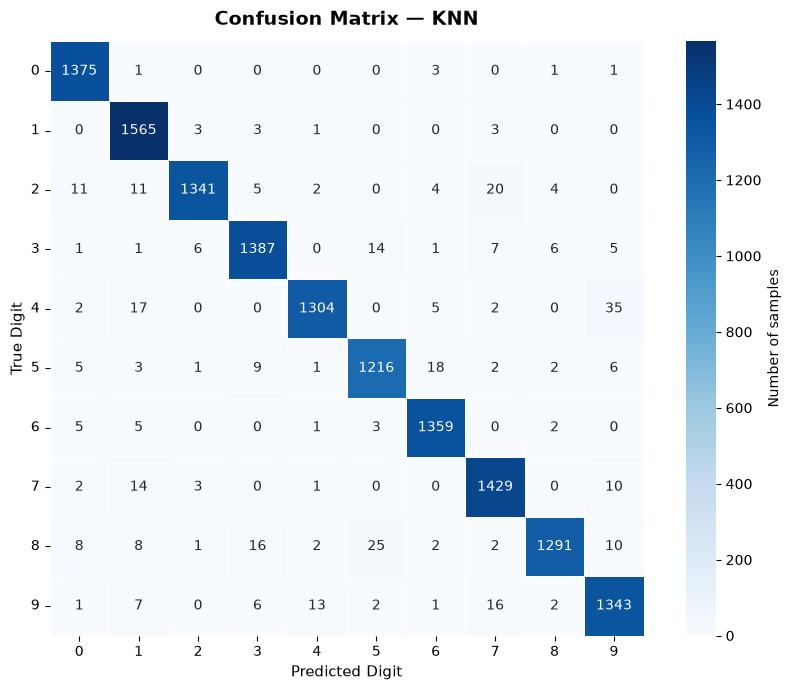


Scikit-learn MLP — Confusion Matrix


,Predicted 0,Predicted 1,Predicted 2,Predicted 3,Predicted 4,Predicted 5,Predicted 6,Predicted 7,Predicted 8,Predicted 9
True 0,1375,0,1,1,0,1,1,0,1,1
True 1,0,1557,5,2,1,0,0,5,3,2
True 2,5,3,1368,1,6,0,1,5,8,1
True 3,1,1,6,1394,0,12,1,5,6,2
True 4,1,3,2,0,1325,0,8,3,0,23
True 5,2,1,1,5,2,1234,5,0,9,4
True 6,6,5,0,1,1,3,1358,0,1,0
True 7,2,3,4,2,5,0,0,1430,4,9
True 8,7,3,5,7,1,5,3,1,1329,4
True 9,3,4,0,4,7,4,1,7,4,1357


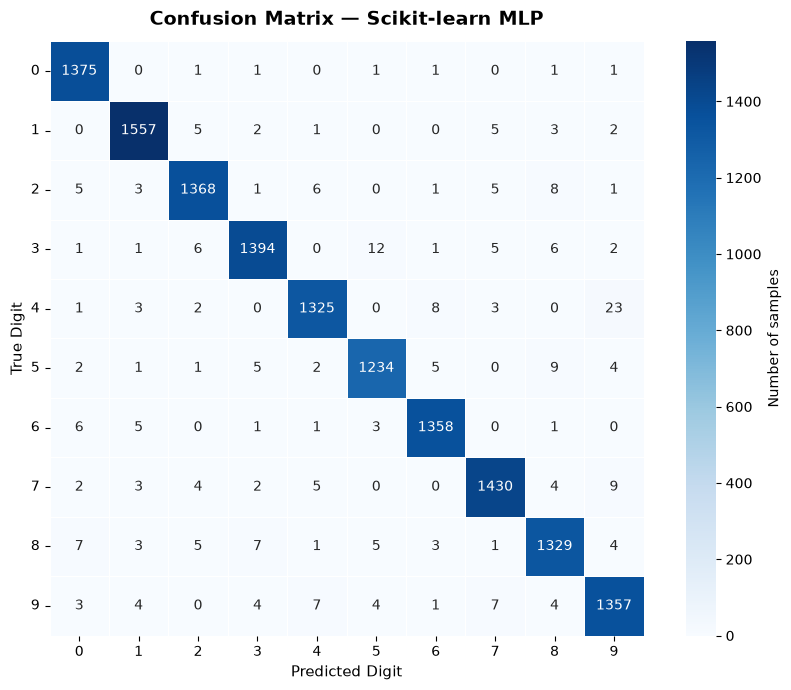


TensorFlow/Keras MLP — Confusion Matrix


,Predicted 0,Predicted 1,Predicted 2,Predicted 3,Predicted 4,Predicted 5,Predicted 6,Predicted 7,Predicted 8,Predicted 9
True 0,1339,0,4,2,3,14,8,1,8,2
True 1,1,1535,10,5,0,7,1,6,8,2
True 2,12,15,1261,21,12,9,20,16,26,6
True 3,9,3,30,1249,1,80,4,17,25,10
True 4,3,10,6,5,1262,0,15,3,10,51
True 5,13,4,5,35,11,1123,22,8,34,8
True 6,14,2,10,0,14,18,1309,0,8,0
True 7,2,9,18,4,7,3,0,1384,2,30
True 8,10,20,17,21,9,56,11,3,1203,15
True 9,9,14,3,16,46,14,2,48,7,1232


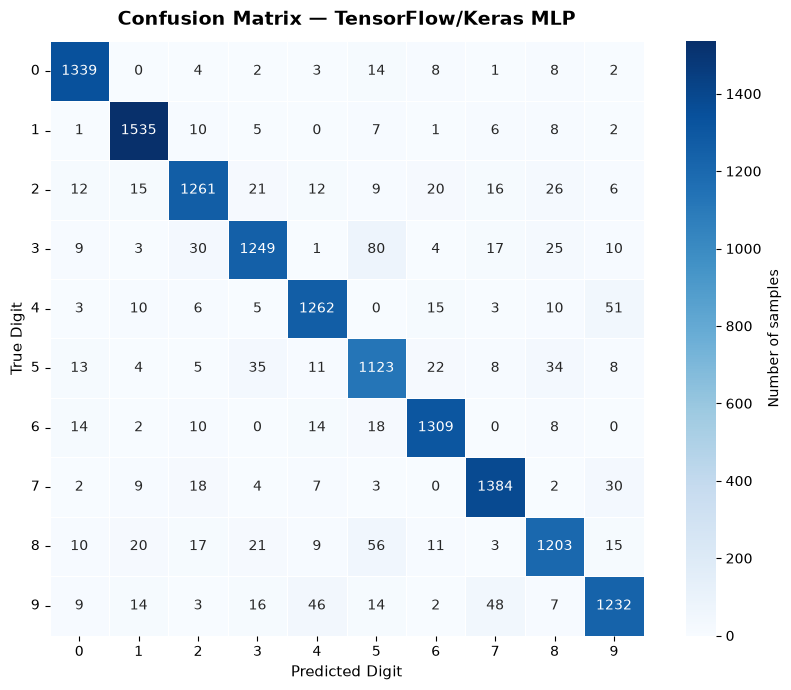

In [54]:
# Compute and visualize confusion matrices for the final models on the test set.

test_confusion_matrices = {
    "KNN": confusion_matrix(y_test, y_test_pred_knn),
    "Scikit-learn MLP": confusion_matrix(y_test, y_test_pred_mlp),
    "TensorFlow/Keras MLP": confusion_matrix(y_test, y_test_pred_keras)
}

for model_name, cm in test_confusion_matrices.items():

    # Display the complete numerical 10 × 10 confusion matrix.
    print(f"\n{model_name} — Confusion Matrix")

    display(pd.DataFrame(
        cm,
        index=[f"True {digit}" for digit in range(10)],
        columns=[f"Predicted {digit}" for digit in range(10)]
    ))

    # Plot the confusion matrix as a heatmap.
    plt.figure(figsize=(9, 7))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        square=True,
        linewidths=0.5,
        linecolor="white",
        xticklabels=range(10),
        yticklabels=range(10),
        cbar_kws={"label": "Number of samples"}
    )

    plt.title(
        f"Confusion Matrix — {model_name}",
        fontsize=14,
        fontweight="bold",
        pad=12
    )

    plt.xlabel("Predicted Digit", fontsize=11)
    plt.ylabel("True Digit", fontsize=11)

    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10, rotation=0)

    plt.tight_layout()
    plt.show()

In [55]:
# Identify the highest-confusion digit and the most-confused digit pair
# for each final model.

confusion_analysis_results = []

for model_name, cm in test_confusion_matrices.items():
    # Total number of samples for each true digit.
    class_totals = cm.sum(axis=1)

    # Correct predictions are on the diagonal.
    correct_predictions = np.diag(cm)

    # Incorrect predictions for each true digit.
    error_counts = class_totals - correct_predictions

    # Error rate for each true digit.
    error_rates = error_counts / class_totals

    # Digit with the highest error rate.
    highest_error_digit = int(np.argmax(error_rates))

    # Largest individual off-diagonal confusion.
    cm_off_diagonal = cm.copy()
    np.fill_diagonal(cm_off_diagonal, 0)

    most_confused_index = np.unravel_index(
        np.argmax(cm_off_diagonal),
        cm_off_diagonal.shape
    )

    most_confused_true_digit = int(most_confused_index[0])
    most_confused_predicted_digit = int(most_confused_index[1])
    most_confused_count = int(cm_off_diagonal[most_confused_index])

    confusion_analysis_results.append({
        "Model": model_name,
        "Highest-confusion digit": highest_error_digit,
        "Highest-confusion error rate": error_rates[highest_error_digit],
        "Most-confused true digit": most_confused_true_digit,
        "Most-confused predicted digit": most_confused_predicted_digit,
        "Most-confused pair count": most_confused_count
    })

confusion_analysis_df = pd.DataFrame(confusion_analysis_results)

display(
    confusion_analysis_df.style.format({
        "Highest-confusion error rate": "{:.2%}",
        "Most-confused pair count": "{:d}"
    })
)

,Model,Highest-confusion digit,Highest-confusion error rate,Most-confused true digit,Most-confused predicted digit,Most-confused pair count
0,KNN,8,5.42%,4,9,35
1,Scikit-learn MLP,4,2.93%,4,9,23
2,TensorFlow/Keras MLP,3,12.54%,3,5,80


### Technical Conclusion

The independent test-set evaluation shows clear differences in performance among the three final models. The Scikit-learn MLP achieved the best overall performance, with an accuracy of 98.05% and weighted Precision, Recall, and F1-score of 98.05%. KNN achieved the second-best performance, with an accuracy of 97.21% and a weighted F1-score of 97.21%, while the TensorFlow/Keras MLP achieved 92.12% accuracy and a weighted F1-score of 92.11%.

The confusion analysis shows that the most difficult digit differs between the models. For KNN, digit 8 had the highest class-specific error rate at 5.42%, while the largest individual confusion was true digit 4 predicted as 9, occurring 35 times. For the Scikit-learn MLP, digit 4 had the highest class-specific error rate at 2.93%, with the largest individual confusion also occurring between 4 and 9, with 23 cases. For the TensorFlow/Keras MLP, digit 3 had the highest class-specific error rate at 12.54%, and the largest individual confusion was true digit 3 predicted as 5, occurring 80 times.

The computational results provide an important trade-off between training and prediction cost. KNN required only 0.0218 seconds to fit, making it by far the fastest model to train, but required 2.3257 seconds to generate predictions for the 14,000 test samples. In contrast, the Scikit-learn MLP required approximately 9.0290 seconds to train but only 0.0057 seconds for test prediction. It therefore provided both the highest test accuracy and the fastest prediction time among the three models. The TensorFlow/Keras MLP had the highest training cost at approximately 28.0449 seconds and required 0.5911 seconds for test prediction, while also achieving the lowest test accuracy.

Overall, the Scikit-learn MLP provides the strongest balance between predictive performance and computational efficiency in this experiment. KNN remains highly competitive in accuracy and has a very low training cost, but its prediction stage is considerably slower. The TensorFlow/Keras MLP performed substantially worse under the selected architecture and training configuration, indicating that its additional computational cost did not translate into improved performance for this particular experiment.


## Phase 5 — Robustness and Generalization

Phase 5 evaluates model behavior under conditions that differ from the standard training and evaluation setup used in the previous phases. The objective is to investigate whether the selected classifier can generalize when some classes are not represented during training and when the input distribution differs from the original MNIST test setting.

For Phase 5, the scikit-learn MLP is selected as the primary model because it achieved the highest independent test accuracy among the evaluated models in Phase 4 (98.05%) and provided substantially faster inference than KNN. The TensorFlow/Keras MLP is not included in this phase because its Phase 4 performance was substantially lower, while KNN is excluded to keep the robustness experiments focused on the strongest model identified in the standard setting.

### Phase 5.1 — Restricted Training with Hidden Classes

In this challenge, selected MNIST classes are completely excluded from the training data. The objective is to evaluate how a classifier trained only on a subset of the original classes behaves when later exposed to examples from classes that were not represented in its training data.

The hidden classes are digits 4 and 9. This choice is motivated by the Phase 4 independent test evaluation, where digit 4 had the highest class-specific error rate for the scikit-learn MLP, while the largest individual confusion was between digits 4 and 9. Therefore, removing both classes provides a direct extension of the error patterns observed in the standard evaluation.

The original train, validation, and test sets remain unchanged. A restricted training set and restricted validation set are created by removing all examples belonging to the selected hidden classes. The original test set is preserved separately for the experiments defined in the previous phases.


In [56]:
# Define hidden and known classes
hidden_classes = [4, 9]
known_classes = [digit for digit in range(10) if digit not in hidden_classes]

print("Hidden classes:", hidden_classes)
print("Known classes:", known_classes)

Hidden classes: [4, 9]
Known classes: [0, 1, 2, 3, 5, 6, 7, 8]


In [57]:
# Create restricted training and validation sets
train_mask = ~np.isin(y_train, hidden_classes)
val_mask = ~np.isin(y_val, hidden_classes)

X_train_restricted = X_train[train_mask]
y_train_restricted = y_train[train_mask]

X_val_restricted = X_val[val_mask]
y_val_restricted = y_val[val_mask]

print("Original training set:", X_train.shape)
print("Restricted training set:", X_train_restricted.shape)

print("Original validation set:", X_val.shape)
print("Restricted validation set:", X_val_restricted.shape)

Original training set: (49000, 784)
Restricted training set: (39352, 784)
Original validation set: (7000, 784)
Restricted validation set: (5622, 784)


In [58]:
# Verify that hidden classes are completely absent
train_classes = np.unique(y_train_restricted)
val_classes = np.unique(y_val_restricted)

print("Classes present in restricted training set:", train_classes)
print("Classes present in restricted validation set:", val_classes)

print(
    "Hidden classes present in restricted training set:",
    np.intersect1d(train_classes, hidden_classes)
)

print(
    "Hidden classes present in restricted validation set:",
    np.intersect1d(val_classes, hidden_classes)
)

Classes present in restricted training set: [0 1 2 3 5 6 7 8]
Classes present in restricted validation set: [0 1 2 3 5 6 7 8]
Hidden classes present in restricted training set: []
Hidden classes present in restricted validation set: []


In [59]:
# Analyze the class distribution after restricting the training set
restricted_distribution = pd.Series(
    y_train_restricted
).value_counts().sort_index()

print("Restricted training class counts:")
print(restricted_distribution)

print("\nRestricted training class proportions:")
print(
    restricted_distribution
    .div(len(y_train_restricted))
    .round(4)
)

Restricted training class counts:
0    4832
1    5514
2    4893
3    4999
5    4419
6    4813
7    5105
8    4777
Name: count, dtype: int64

Restricted training class proportions:
0    0.1228
1    0.1401
2    0.1243
3    0.1270
5    0.1123
6    0.1223
7    0.1297
8    0.1214
Name: count, dtype: float64


In [60]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
import time

# Train the scikit-learn MLP using the final configuration selected in Phase 3.
# The model is trained only on the restricted dataset, where digits 4 and 9 are absent.

mlp_restricted = MLPClassifier(
    hidden_layer_sizes=(128,),
    alpha=0.001,
    random_state=42
)

# Measure training time.
restricted_fit_start = time.perf_counter()

mlp_restricted.fit(
    X_train_restricted,
    y_train_restricted
)

restricted_fit_time = (
    time.perf_counter() - restricted_fit_start
)

print("Restricted Scikit-learn MLP")
print(f"Hidden layer sizes: {mlp_restricted.hidden_layer_sizes}")
print(f"Alpha: {mlp_restricted.alpha}")
print(f"Actual iterations: {mlp_restricted.n_iter_}")
print(f"Training samples: {len(y_train_restricted)}")
print(f"Training classes: {np.unique(y_train_restricted)}")
print(f"Fit time: {restricted_fit_time:.4f} seconds")

/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


Restricted Scikit-learn MLP
Hidden layer sizes: (128,)
Alpha: 0.001
Actual iterations: 50
Training samples: 39352
Training classes: [0 1 2 3 5 6 7 8]
Fit time: 8.1351 seconds


In [61]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Evaluate the restricted MLP on validation examples from known classes only.

restricted_val_pred = mlp_restricted.predict(X_val_restricted)

restricted_val_accuracy = accuracy_score(
    y_val_restricted,
    restricted_val_pred
)

restricted_val_precision = precision_score(
    y_val_restricted,
    restricted_val_pred,
    average="weighted"
)

restricted_val_recall = recall_score(
    y_val_restricted,
    restricted_val_pred,
    average="weighted"
)

restricted_val_f1 = f1_score(
    y_val_restricted,
    restricted_val_pred,
    average="weighted"
)

print("Restricted MLP — Known-Class Validation")
print(f"Validation samples: {len(y_val_restricted)}")
print(f"Validation classes: {np.unique(y_val_restricted)}")
print(f"Validation accuracy: {restricted_val_accuracy:.4f}")
print(f"Weighted precision: {restricted_val_precision:.4f}")
print(f"Weighted recall: {restricted_val_recall:.4f}")
print(f"Weighted F1-score: {restricted_val_f1:.4f}")

Restricted MLP — Known-Class Validation
Validation samples: 5622
Validation classes: [0 1 2 3 5 6 7 8]
Validation accuracy: 0.9703
Weighted precision: 0.9706
Weighted recall: 0.9703
Weighted F1-score: 0.9703


/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


Restricted MLP — Known-Class Validation Confusion Matrix
[[682   1   3   1   0   2   0   1]
 [  0 781   3   0   0   1   2   1]
 [  1   2 689   0   1   1   4   1]
 [  1   1  19 666  10   0   6  11]
 [  3   0   1   4 606   5   1  11]
 [  4   3   1   0   4 676   0   0]
 [  1   9  11   1   0   0 706   1]
 [  0   9   9   3   5   6   2 649]]


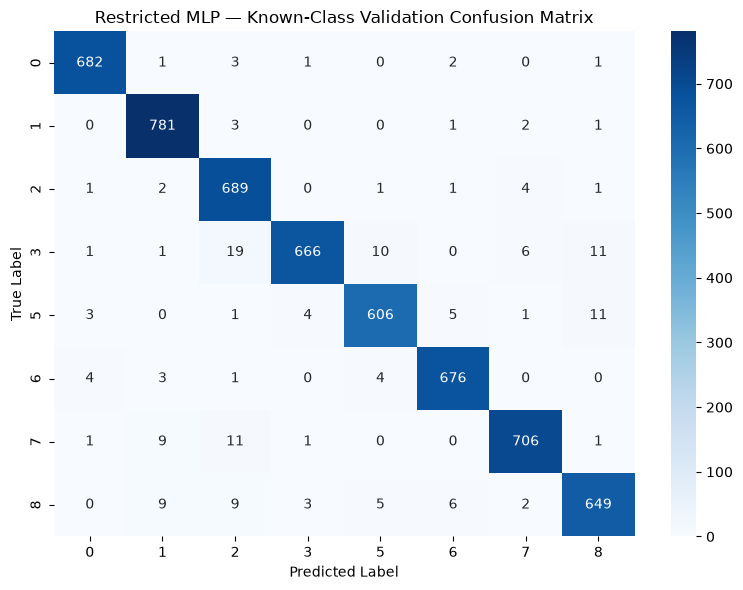

In [62]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion matrix for known-class validation
known_classes = [0, 1, 2, 3, 5, 6, 7, 8]

restricted_cm = confusion_matrix(
    y_val_restricted,
    restricted_val_pred,
    labels=known_classes
)

print("Restricted MLP — Known-Class Validation Confusion Matrix")
print(restricted_cm)

plt.figure(figsize=(8, 6))

sns.heatmap(
    restricted_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=known_classes,
    yticklabels=known_classes
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Restricted MLP — Known-Class Validation Confusion Matrix")
plt.tight_layout()
plt.show()


### Interpretation and Conclusion

The class masking procedure was successfully implemented by completely removing digits 4 and 9 from both the training and validation datasets. The restricted training set contained 39,352 samples and the restricted validation set contained 5,622 samples, with only the eight remaining classes represented. The original test set was preserved unchanged for the subsequent robustness experiments.

After retraining the scikit-learn MLP on the restricted dataset, the model achieved 97.03% validation accuracy on the eight classes that were represented during training. The weighted precision, recall, and F1-score were also approximately 97%, indicating that the classifier maintained strong performance on the classes it was trained to recognize.

These results confirm that the restricted-training experiment was successfully established. The model was able to learn the remaining eight MNIST classes despite having no labeled examples of digits 4 and 9. Importantly, this result should not be interpreted as evidence that the model can recognize the hidden classes. Instead, Challenge A establishes the experimental condition required for Challenge B: a classifier trained without any examples of selected classes.

Therefore, the class masking procedure was effective and provided a controlled setting for investigating how a closed-set classifier behaves when subsequently exposed to previously unseen classes.


### Phase 5.2 — Unseen-Class / OOD Inference

In this challenge, the restricted classifier is evaluated on examples belonging exclusively to the classes that were completely absent from its training data. The objective is to investigate how a closed-set classifier behaves when it receives inputs from classes that it was never trained to recognize.

The hidden classes are digits 4 and 9, which were removed from both the restricted training and validation sets in Phase 5.1. The restricted scikit-learn MLP therefore learned to classify only the eight known classes: 0, 1, 2, 3, 5, 6, 7, and 8.

For this experiment, the original test set remains untouched and is used to create a dedicated hidden-class test subset containing only digits 4 and 9. They are used exclusively to evaluate how the already-trained restricted model responds to unseen classes.

Because the scikit-learn MLP is a closed-set multiclass classifier, it does not contain an explicit "unknown" or "other" class. When presented with an image of digit 4 or 9, the model must therefore assign it to one of the eight classes that it knows. This makes it possible to analyze which known classes the unseen digits are mapped to and whether certain classes systematically attract these incorrect predictions.

The evaluation will examine the prediction distribution for the hidden classes and the resulting confusion patterns. Model confidence will also be investigated to determine whether the classifier remains uncertain when processing unseen classes or whether it can produce high-confidence predictions despite being wrong. This illustrates an important limitation of closed-set classifiers: a high predicted probability does not necessarily indicate that the input belongs to a class represented in the training data.

This experiment is treated as an operational MNIST unseen-class/OOD demonstration rather than a complete real-world out-of-distribution benchmark. Its purpose is to demonstrate the behavior of the selected classifier when the input contains classes outside its learned label space.


In [63]:
# Create the hidden-class test subset from the untouched original test set.

hidden_test_mask = np.isin(y_test, hidden_classes)

X_test_hidden = X_test[hidden_test_mask]
y_test_hidden = y_test[hidden_test_mask]

print("Hidden-class test subset")
print(f"Samples: {len(y_test_hidden)}")
print(f"Classes: {np.unique(y_test_hidden)}")

print("\nClass counts:")
print(
    pd.Series(y_test_hidden)
    .value_counts()
    .sort_index()
)

Hidden-class test subset
Samples: 2756
Classes: [4 9]

Class counts:
4    1365
9    1391
Name: count, dtype: int64


In [64]:
# Predict the hidden classes using the restricted MLP.
# The model has never been trained on digits 4 or 9.

hidden_test_pred = mlp_restricted.predict(X_test_hidden)

print("Restricted MLP — Hidden-Class Inference")
print(f"Test samples: {len(y_test_hidden)}")
print(f"True classes: {np.unique(y_test_hidden)}")
print(f"Predicted classes: {np.unique(hidden_test_pred)}")

print("\nPrediction distribution:")
print(
    pd.Series(hidden_test_pred)
    .value_counts()
    .sort_index()
)

Restricted MLP — Hidden-Class Inference
Test samples: 2756
True classes: [4 9]
Predicted classes: [0 1 2 3 5 6 7 8]

Prediction distribution:
0     138
1     193
2     209
3     134
5     343
6     102
7    1075
8     562
Name: count, dtype: int64


/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [65]:
# Analyze how each hidden class is mapped to the known classes.

hidden_prediction_table = pd.crosstab(
    y_test_hidden,
    hidden_test_pred
)

# Ensure all known classes are represented as columns.
hidden_prediction_table = hidden_prediction_table.reindex(
    columns=known_classes,
    fill_value=0
)

print("Hidden-Class Prediction Distribution")
print(hidden_prediction_table)

Hidden-Class Prediction Distribution
col_0    0    1    2    3    5   6    7    8
row_0                                       
4      109  118  172   32  199  97  278  360
9       29   75   37  102  144   5  797  202


In [66]:
# Obtain class probabilities for the hidden-class test subset.
# The model can only assign probability to the eight classes seen during training.

hidden_test_proba = mlp_restricted.predict_proba(X_test_hidden)

print("Hidden-class probability output")
print(f"Probability array shape: {hidden_test_proba.shape}")
print(f"Model classes: {mlp_restricted.classes_}")

print("\nProbability range:")
print(f"Minimum probability: {hidden_test_proba.min():.6f}")
print(f"Maximum probability: {hidden_test_proba.max():.6f}")

print("\nProbability sums for first 5 samples:")
print(hidden_test_proba[:5].sum(axis=1))

Hidden-class probability output
Probability array shape: (2756, 8)
Model classes: [0 1 2 3 5 6 7 8]

Probability range:
Minimum probability: 0.000000
Maximum probability: 1.000000

Probability sums for first 5 samples:
[1. 1. 1. 1. 1.]


/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [67]:
# Evaluate model confidence on unseen classes.
# Confidence is the highest predicted probability among the
# eight known classes.

hidden_confidence = hidden_test_proba.max(axis=1)

print("Restricted MLP — Confidence on Hidden Classes")
print(f"Mean confidence:   {hidden_confidence.mean():.4f}")
print(f"Median confidence: {np.median(hidden_confidence):.4f}")
print(f"Minimum confidence: {hidden_confidence.min():.4f}")
print(f"Maximum confidence: {hidden_confidence.max():.4f}")

Restricted MLP — Confidence on Hidden Classes
Mean confidence:   0.9811
Median confidence: 1.0000
Minimum confidence: 0.3518
Maximum confidence: 1.0000


Restricted MLP — Hidden-Class Inference Confusion Matrix
Predicted Known Class    0    1    2    3    5   6    7    8
True Class                                                  
4                      109  118  172   32  199  97  278  360
9                       29   75   37  102  144   5  797  202


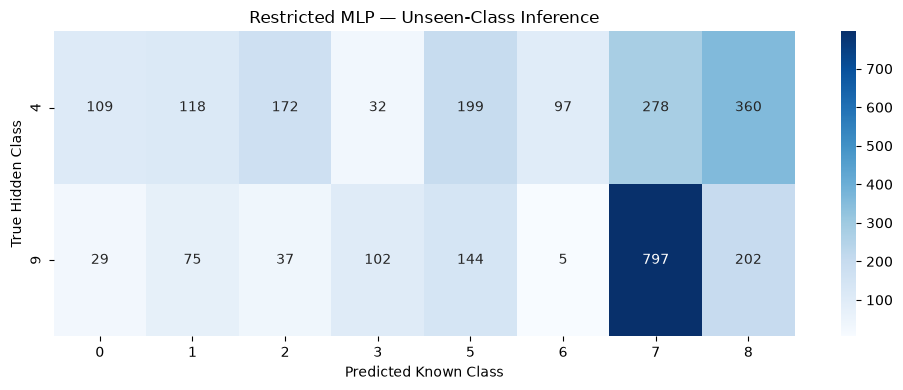

In [68]:
# Unseen-Class Inference
# Build and visualize the confusion matrix for the hidden classes.

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convert the hidden-class prediction table to a NumPy matrix
hidden_cm = hidden_prediction_table.to_numpy()

# Create a labeled DataFrame for easier interpretation
hidden_cm_df = pd.DataFrame(
    hidden_cm,
    index=hidden_classes,
    columns=known_classes
)

hidden_cm_df.index.name = "True Class"
hidden_cm_df.columns.name = "Predicted Known Class"

print("Restricted MLP — Hidden-Class Inference Confusion Matrix")
print(hidden_cm_df)

# Plot the matrix
plt.figure(figsize=(10, 4))

sns.heatmap(
    hidden_cm_df,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted Known Class")
plt.ylabel("True Hidden Class")
plt.title("Restricted MLP — Unseen-Class Inference")
plt.tight_layout()
plt.show()

### Interpretation and Conclusion

The unseen-class experiment demonstrated a clear limitation of the restricted scikit-learn MLP. When evaluated exclusively on the hidden digits 4 and 9, the model could not correctly classify any sample because these classes were completely absent from its training data and were not part of its output label space. All 2,756 hidden-class samples were therefore assigned to one of the eight known classes.

The resulting inference matrix shows that these incorrect predictions were not random. Digit 4 was most frequently classified as 8 (360 samples) or 7 (278 samples), while digit 9 was particularly strongly assigned to class 7 (797 of 1,391 samples, approximately 57.3%), followed by classes 8 and 5. This indicates that the model projects unseen inputs onto the decision boundaries of the classes it knows rather than identifying them as unknown.

The confidence analysis provides an important additional observation. Despite every prediction being incorrect with respect to the true hidden class, the model produced a mean maximum predicted probability of 98.11%, with a median of 100%. This demonstrates false certainty: the model can be highly confident in a prediction even when the input belongs to a class that was never represented during training.

Overall, Challenge B demonstrates that a standard closed-set MLP does not inherently detect unseen classes. Its predicted probabilities express confidence among the classes available to the model, rather than confirming that the input actually belongs to one of those classes. This experiment therefore provides an operational demonstration of unseen-class/OOD behavior in MNIST and highlights the importance of explicit mechanisms for unknown-class or out-of-distribution detection in applications where unseen inputs may occur.


### 5.3 — Challenge C: Inference with Own Handwritten Images

In this challenge, the generalization ability of the best-performing model developed during the previous phases is evaluated using handwritten digit images created independently of the MNIST dataset.

The handwritten digits were created digitally on a white background using black handwriting. The ten images represent the digits from 0 to 9 and are stored as PNG files in the project data directory. These images were not used during model training, validation, model selection, or hyperparameter optimization.

The best-performing model identified during Phase 4 is the Scikit-learn `MLPClassifier`, which achieved a test accuracy of 98.05% on the original MNIST test set. This previously trained model will be reused unchanged in Challenge C.

The purpose of this challenge is to evaluate how well a model trained on the MNIST dataset generalizes to handwritten digits produced through a different image-generation process.

The preprocessing pipeline will transform the own handwritten images into a representation compatible with the MNIST-based model. The procedure will consist of:

1. Loading the own handwritten PNG images.
2. Converting the images to grayscale.
3. Inverting the pixel intensities so that the black handwritten digit becomes bright and the white background becomes dark.
4. Detecting the digit and determining its bounding box.
5. Cropping the digit.
6. Resizing the digit while preserving its aspect ratio.
7. Centering the digit on a 28×28 black canvas.
8. Normalizing pixel intensities to the range [0.0, 1.0].
9. Passing the processed images to the previously trained Scikit-learn MLP.
10. Visualizing each processed handwritten digit together with the model's predicted probability distribution.

### 5.3.1 — Own Handwritten Image Directory

The own handwritten PNG images are stored separately from the previously photographed images. This keeps the original photographs available as an archive while ensuring that the Challenge C experiment uses only the newly created digital handwritten images.


In [69]:
# Import Path to work with project directories in a platform-independent way
from pathlib import Path

# Define the directory containing the new digitally created handwritten images
OWN_IMAGES_DIR = Path("../data/own_images")

# Define the directory where the processed 28×28 images will be stored later
PROCESSED_IMAGES_DIR = Path("../data/own_images_processed")

# Create the processed-image directory if it does not already exist
PROCESSED_IMAGES_DIR.mkdir(parents=True, exist_ok=True)

# Print the directories being used by the Challenge C pipeline
print("Own handwritten image directory:")
print(OWN_IMAGES_DIR.resolve())

print()
print("Processed image directory:")
print(PROCESSED_IMAGES_DIR.resolve())

Own handwritten image directory:
/Users/anandastaats/mnist-multiclass-predictive-pipeline/data/own_images

Processed image directory:
/Users/anandastaats/mnist-multiclass-predictive-pipeline/data/own_images_processed


### 5.3.2 — Inspect the Own Handwritten Images

Before applying any preprocessing, the input files are inspected to verify that all ten handwritten digits are available and that the files can be loaded successfully.

The expected filenames correspond to the ten digit classes from 0 to 9. The original dimensions are also recorded because the images will subsequently be transformed into the 28×28 format required by the trained MNIST classifier.


In [70]:
# Import PIL for opening and inspecting PNG images
from PIL import Image

# Collect all PNG files from the own handwritten image directory
# The suffix check is case-insensitive so both .png and .PNG are accepted
own_image_paths = sorted(
    path for path in OWN_IMAGES_DIR.iterdir()
    if path.is_file() and path.suffix.lower() == ".png"
)

# Print the number of PNG files found
print(f"Number of PNG files found: {len(own_image_paths)}")
print()

# Inspect each handwritten image
for image_path in own_image_paths:
    # Open the handwritten image
    image = Image.open(image_path)

    # Print the filename and original image dimensions
    print(f"{image_path.name}: size={image.size}, mode={image.mode}")

Number of PNG files found: 10

IMG_5745.PNG: size=(1536, 1662), mode=RGBA
IMG_5746.PNG: size=(1536, 1692), mode=RGBA
IMG_5747.PNG: size=(1536, 1740), mode=RGBA
IMG_5748.PNG: size=(1536, 1712), mode=RGBA
IMG_5749.PNG: size=(1536, 2112), mode=RGBA
IMG_5751.PNG: size=(1536, 1998), mode=RGBA
IMG_5752.PNG: size=(1536, 2020), mode=RGBA
IMG_5753.PNG: size=(1536, 1728), mode=RGBA
IMG_5754.PNG: size=(1536, 1758), mode=RGBA
IMG_5755.PNG: size=(1536, 1844), mode=RGBA


### 5.3.3 — Visual Inspection of Original Images

The original handwritten images are displayed before preprocessing to verify their visual orientation, handwriting, background, and overall image quality.

At this stage, the images should still show the original white background and black handwritten digits. No preprocessing is performed in this step.


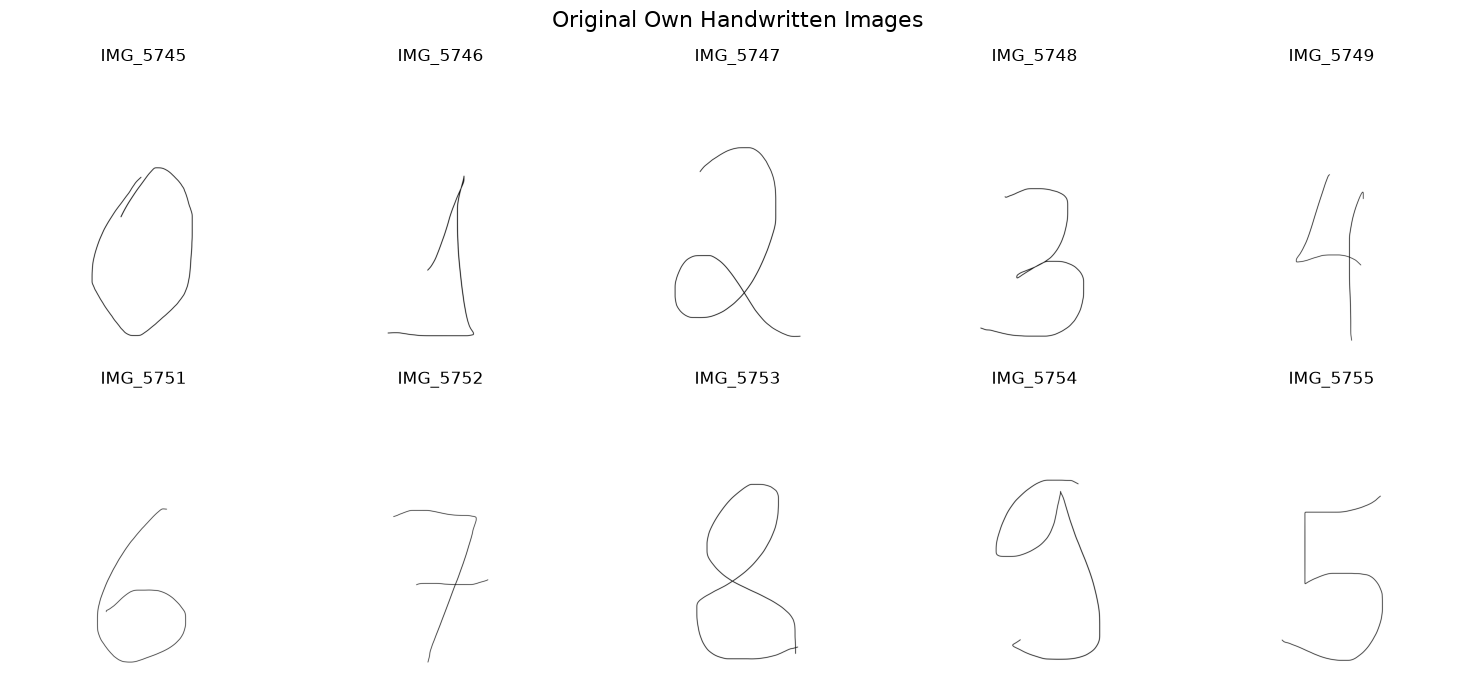

In [71]:
# Import matplotlib for displaying the handwritten images
import matplotlib.pyplot as plt

# Create a figure containing one subplot for each handwritten digit
fig, axes = plt.subplots(2, 5, figsize=(15, 7))

# Flatten the axes array to make iteration easier
axes = axes.ravel()

# Display each handwritten image
for index, image_path in enumerate(own_image_paths):
    # Open the image
    image = Image.open(image_path)

    # Display the image in the corresponding subplot
    axes[index].imshow(image)

    # Use the filename as the subplot title
    axes[index].set_title(image_path.stem)

    # Hide the axis because only the image itself is relevant
    axes[index].axis("off")

# Add a title describing the figure
fig.suptitle("Original Own Handwritten Images", fontsize=16)

# Adjust the layout to prevent overlapping elements
plt.tight_layout()

# Display the figure
plt.show()

### 5.3.4 — Preprocessing Pipeline

The own handwritten images use a white background with black handwritten digits. Because the trained MNIST model expects bright digits on a dark background, the images must first be converted to grayscale and their pixel intensities inverted.

The preprocessing pipeline then identifies the handwritten digit, removes unnecessary background, preserves the digit's aspect ratio, and centers it on a 28×28 black canvas. Finally, the pixel intensities are normalized to the range [0.0, 1.0], producing an input representation compatible with the MNIST-trained Scikit-learn MLP.

The preprocessing is applied independently to each image. No information from the true digit labels is used during preprocessing or prediction.

In [72]:
# Import NumPy for numerical image processing
import numpy as np

# Import PIL image-processing tools
from PIL import Image, ImageOps

# Define the target MNIST image size
TARGET_SIZE = 28

# Define the preprocessing function for one handwritten image
def preprocess_handwritten_image(image_path):
    # Open the image and convert it to grayscale
    image = Image.open(image_path).convert("L")

    # Convert the grayscale image to a NumPy array
    image_array = np.array(image)

    # Invert the grayscale intensities:
    # white background becomes dark and black handwriting becomes bright
    inverted_array = 255 - image_array

    # Convert the inverted array back to a PIL image
    inverted_image = Image.fromarray(inverted_array.astype(np.uint8))

    # Convert the image to a NumPy array for thresholding
    inverted_array = np.array(inverted_image)

    # Create a binary mask identifying pixels belonging to the handwritten digit
    # A pixel is considered part of the digit when its intensity is above zero
    digit_mask = inverted_array > 0

    # Find the coordinates of all non-background pixels
    coordinates = np.argwhere(digit_mask)

    # Raise an error if no handwritten digit pixels are detected
    if coordinates.size == 0:
        raise ValueError(f"No handwritten digit detected in {image_path.name}")

    # Determine the bounding box of the detected digit
    min_row, min_col = coordinates.min(axis=0)
    max_row, max_col = coordinates.max(axis=0)

    # Crop the image to the detected digit bounding box
    cropped_array = inverted_array[min_row:max_row + 1, min_col:max_col + 1]

    # Convert the cropped digit back to a PIL image
    cropped_image = Image.fromarray(cropped_array.astype(np.uint8))

    # Determine the dimensions of the cropped digit
    crop_width, crop_height = cropped_image.size

    # Define the maximum dimension used before placing the digit on the 28×28 canvas
    max_dimension = 20

    # Calculate the scaling factor while preserving the original aspect ratio
    scale = max_dimension / max(crop_width, crop_height)

    # Calculate the new dimensions after resizing
    new_width = max(1, round(crop_width * scale))
    new_height = max(1, round(crop_height * scale))

    # Resize the digit using high-quality Lanczos interpolation
    resized_image = cropped_image.resize(
        (new_width, new_height),
        Image.Resampling.LANCZOS
    )

    # Create a black 28×28 canvas
    canvas = Image.new("L", (TARGET_SIZE, TARGET_SIZE), color=0)

    # Calculate the coordinates required to center the resized digit
    left = (TARGET_SIZE - new_width) // 2
    top = (TARGET_SIZE - new_height) // 2

    # Paste the resized digit onto the centered canvas
    canvas.paste(resized_image, (left, top))

    # Convert the centered image to a NumPy array
    processed_array = np.array(canvas, dtype=np.float32)

    # Normalize pixel intensities to the range [0.0, 1.0]
    processed_array /= 255.0

    # Return both the processed image and the normalized flattened representation
    return processed_array, processed_array.reshape(1, -1)

### 5.3.5 — Apply Preprocessing to the Own Handwritten Images

The preprocessing function is now applied to all ten own handwritten images.

For each image, the pipeline converts the original white-background/black-stroke image into a centered 28×28 representation with the same general format expected by the MNIST-trained classifier.

The processed images and their flattened versions are stored separately so that the preprocessing results can be inspected before any predictions are performed.

In [73]:
# Create lists to store the processed images and their corresponding filenames
processed_images = []
processed_image_names = []

# Process each own handwritten image independently
for image_path in own_image_paths:
    # Apply the preprocessing pipeline to the current handwritten image
    processed_image, _ = preprocess_handwritten_image(image_path)

    # Store the processed 28×28 image
    processed_images.append(processed_image)

    # Store the original filename for later identification
    processed_image_names.append(image_path.name)

# Convert the list of processed images into a NumPy array
processed_images = np.array(processed_images)

# Print the resulting array shape
print(f"Processed images shape: {processed_images.shape}")

# Print the minimum and maximum pixel values
print(f"Minimum pixel value: {processed_images.min():.4f}")
print(f"Maximum pixel value: {processed_images.max():.4f}")

# Print the filenames in the order used for processing
print()
print("Processed image order:")
for index, filename in enumerate(processed_image_names):
    print(f"{index}: {filename}")

Processed images shape: (10, 28, 28)
Minimum pixel value: 0.0000
Maximum pixel value: 0.2235

Processed image order:
0: IMG_5745.PNG
1: IMG_5746.PNG
2: IMG_5747.PNG
3: IMG_5748.PNG
4: IMG_5749.PNG
5: IMG_5751.PNG
6: IMG_5752.PNG
7: IMG_5753.PNG
8: IMG_5754.PNG
9: IMG_5755.PNG


### 5.3.6 — Visual Inspection of Processed Images

The preprocessed handwritten digits are visualized in their final 28×28 representation before inference.

This inspection verifies that the handwritten digits were correctly detected, cropped, resized, centered, inverted, and normalized.

The visualization is performed before prediction so that any preprocessing problems can be identified independently of the model's predictions.

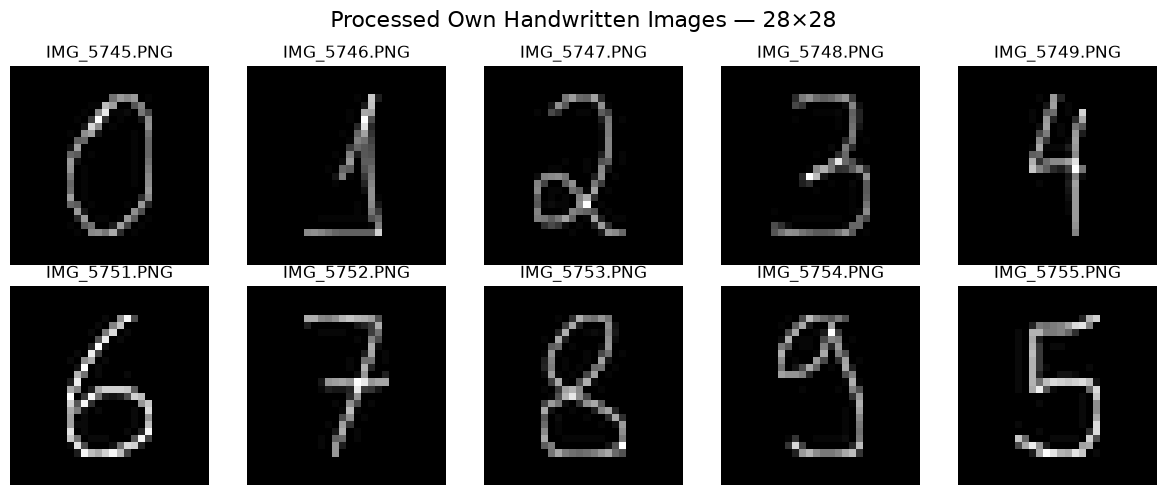

In [74]:
# Import matplotlib for visualizing the processed handwritten digits
import matplotlib.pyplot as plt

# Create a figure containing one subplot for each processed handwritten digit
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

# Flatten the axes array to make iteration easier
axes = axes.ravel()

# Display each processed 28×28 handwritten digit
for index, processed_image in enumerate(processed_images):
    # Display the normalized image using a grayscale color map
    axes[index].imshow(processed_image, cmap="gray")

    # Use the original filename as the subplot title
    axes[index].set_title(processed_image_names[index])

    # Hide the axis because only the processed image is relevant
    axes[index].axis("off")

# Add a title describing the processed images
fig.suptitle("Processed Own Handwritten Images — 28×28", fontsize=16)

# Adjust the layout to prevent overlapping elements
plt.tight_layout()

# Display the figure
plt.show()

### 5.3.7 — Inference with the Scikit-learn MLP

The preprocessed own handwritten images are now passed to the previously trained Scikit-learn `MLPClassifier`.

The model is the best-performing model identified in Phase 4, with a test accuracy of 98.05% on the original MNIST test set. It is reused exactly as trained and is not retrained, fine-tuned, or modified using the own handwritten images.

For each handwritten image, the model produces a predicted digit and a probability distribution across the ten MNIST classes (0–9).

The true digit is inferred from the filename only for later evaluation and visualization. These labels are not provided to the model during inference.

In [77]:
# Create the flattened model input from the processed 28×28 images
# Each image is converted from 28×28 pixels into 784 features
own_images_flat = processed_images.reshape(len(processed_images), -1)

# Verify the shape expected by the Scikit-learn MLP
print(f"Model input shape: {own_images_flat.shape}")

# Generate predictions using the previously trained Phase 4 Scikit-learn MLP
# The model is used unchanged and is not retrained on the own handwritten images
own_predictions = mlp_model.predict(own_images_flat)

# Generate class probabilities for every handwritten image
own_probabilities = mlp_model.predict_proba(own_images_flat)

# Print the predicted class for each handwritten image
print()
print("Predictions:")
for index, filename in enumerate(processed_image_names):
    print(f"{filename}: predicted={own_predictions[index]}")

# Verify the probability matrix dimensions
print()
print(f"Probability matrix shape: {own_probabilities.shape}")

# Verify the probability values
print(f"Probability range: {own_probabilities.min():.4f} to {own_probabilities.max():.4f}")

Model input shape: (10, 784)

Predictions:
IMG_5745.PNG: predicted=5
IMG_5746.PNG: predicted=5
IMG_5747.PNG: predicted=2
IMG_5748.PNG: predicted=5
IMG_5749.PNG: predicted=4
IMG_5751.PNG: predicted=5
IMG_5752.PNG: predicted=2
IMG_5753.PNG: predicted=5
IMG_5754.PNG: predicted=5
IMG_5755.PNG: predicted=5

Probability matrix shape: (10, 10)
Probability range: 0.0033 to 0.6771


/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/mnist-pipeline/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


### 5.3.8 — Prediction Probability Visualization

The predictions generated by the fixed Scikit-learn MLP are visualized together with the corresponding processed handwritten images.

For each own handwritten image, the left panel shows the final 28×28 representation provided to the model, while the right panel shows the predicted probability distribution across the ten MNIST digit classes.

The visualization makes it possible to assess not only the predicted class but also the model's confidence and the distribution of alternative predictions.

Incorrect predictions are retained and displayed because they provide important evidence about the model's generalization to independently created handwritten images.

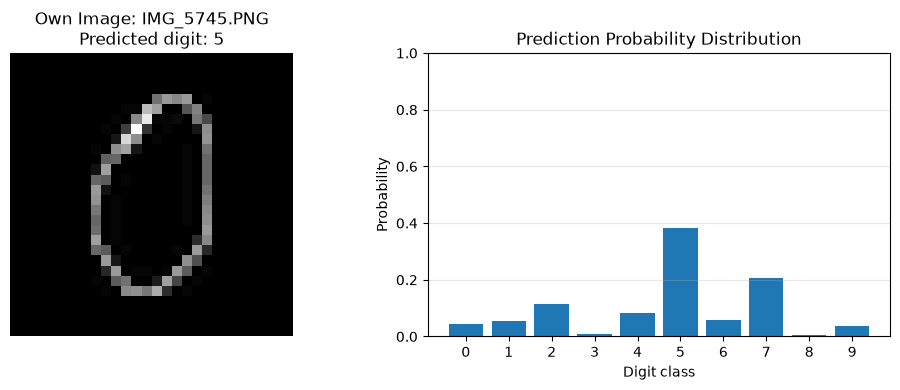

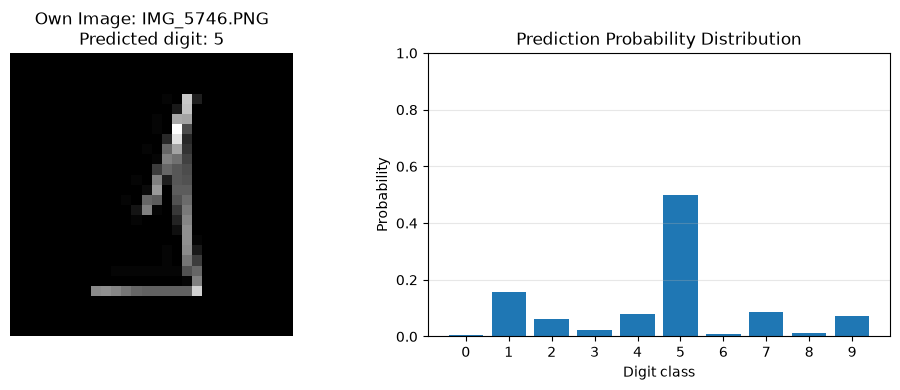

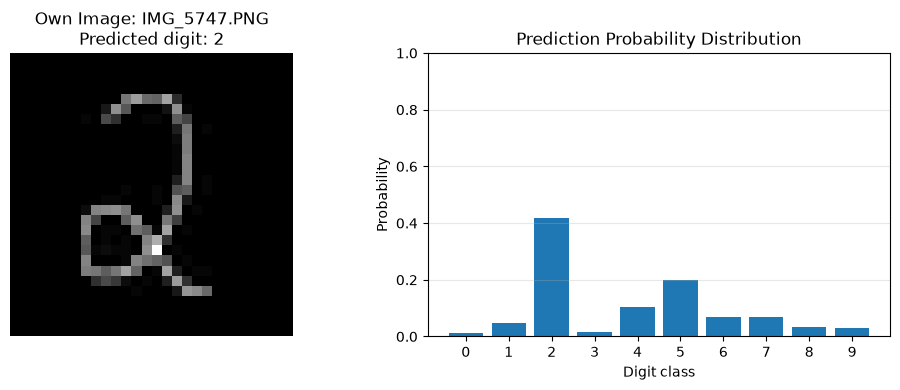

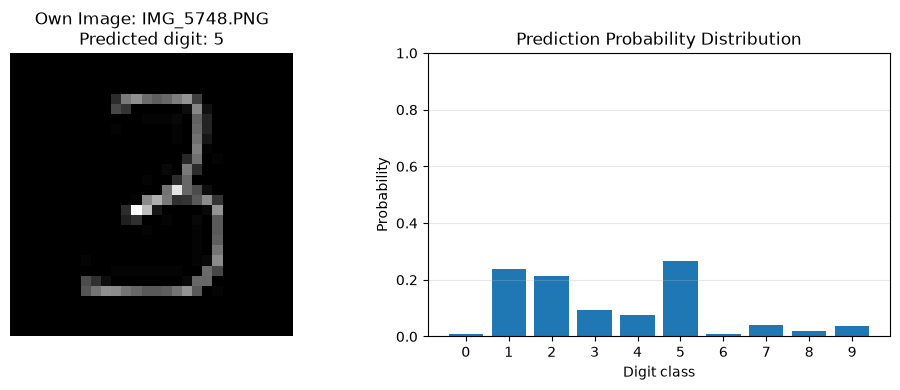

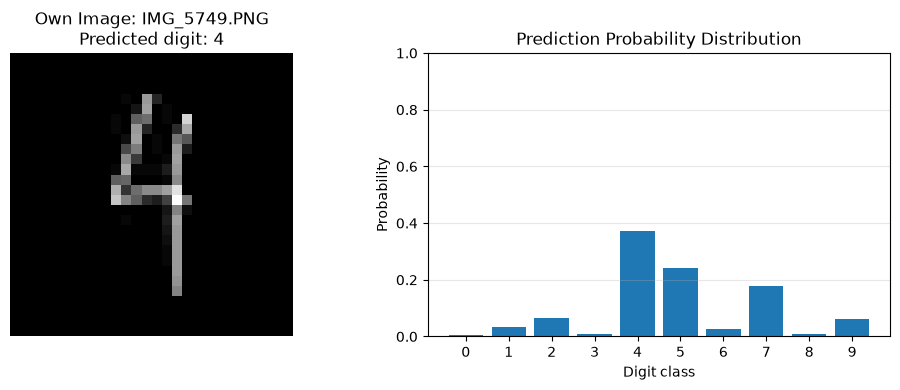

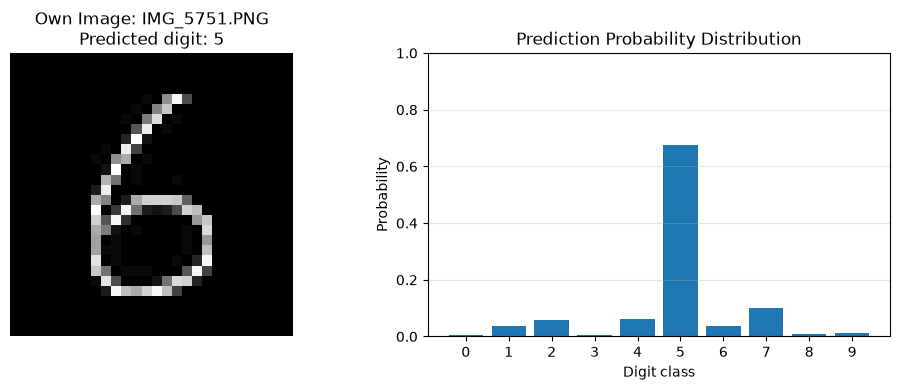

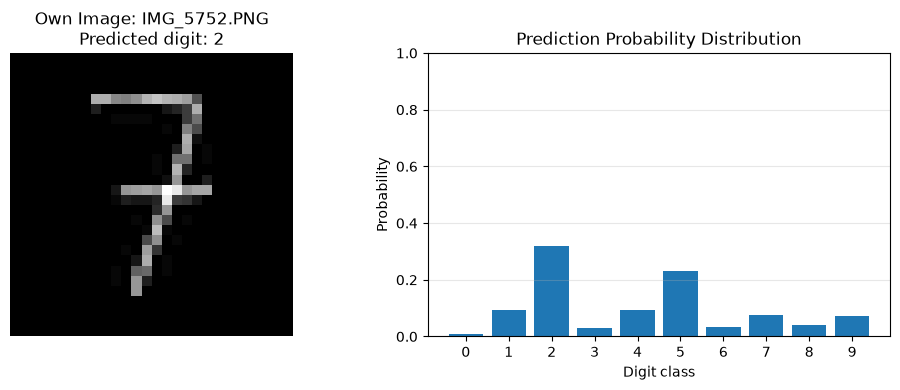

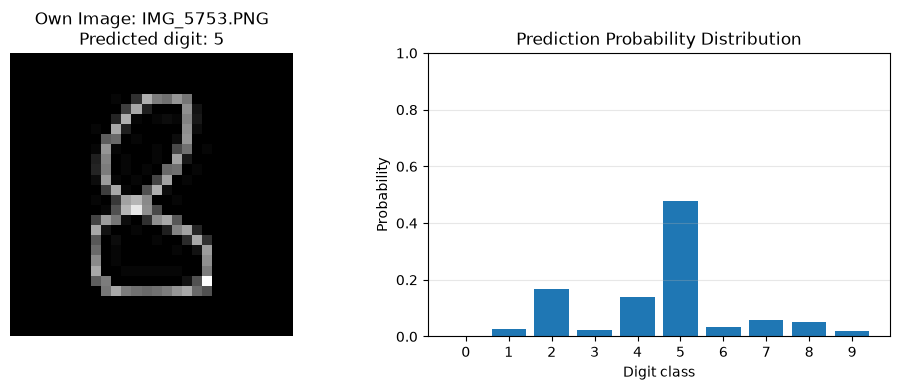

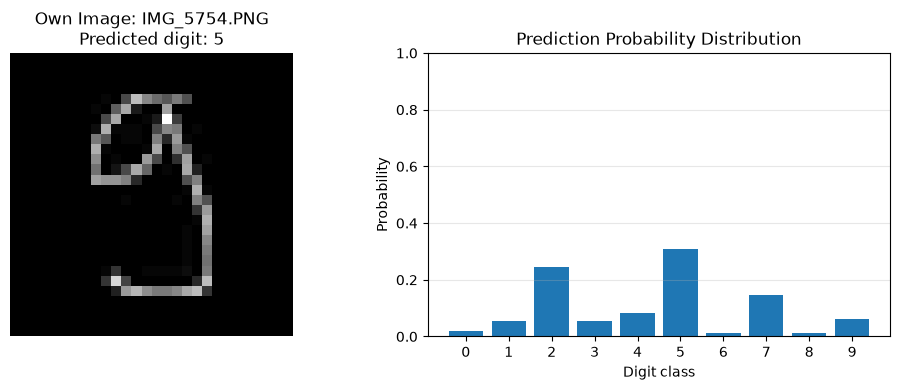

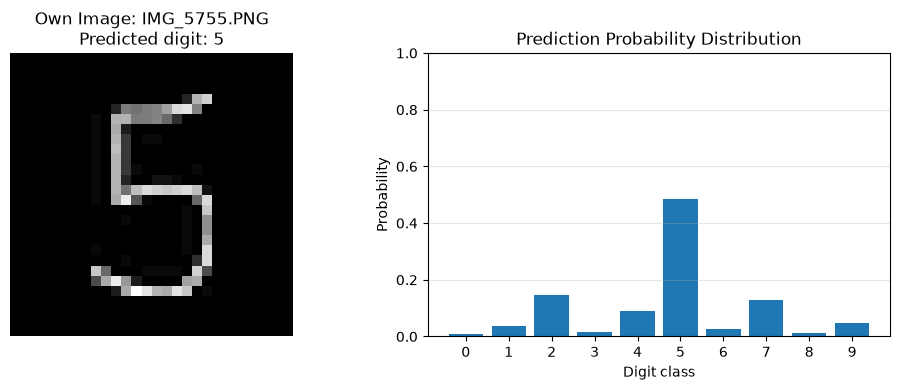

In [78]:
# Import matplotlib for visualizing the processed images and prediction probabilities
import matplotlib.pyplot as plt

# Define the ten MNIST digit classes
digit_classes = np.arange(10)

# Create one figure for each handwritten image
for index, processed_image in enumerate(processed_images):
    # Create two side-by-side panels:
    # the processed handwritten image and its probability distribution
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # Display the processed 28×28 handwritten digit
    axes[0].imshow(processed_image, cmap="gray")

    # Add the predicted class to the image title
    axes[0].set_title(
        f"Own Image: {processed_image_names[index]}\n"
        f"Predicted digit: {own_predictions[index]}"
    )

    # Hide the image axes
    axes[0].axis("off")

    # Display the model's probability distribution across digits 0–9
    axes[1].bar(digit_classes, own_probabilities[index])

    # Highlight the predicted class on the probability graph
    axes[1].set_title("Prediction Probability Distribution")

    # Label the x-axis with the possible digit classes
    axes[1].set_xlabel("Digit class")

    # Label the y-axis with the predicted probability
    axes[1].set_ylabel("Probability")

    # Display all ten digit classes on the x-axis
    axes[1].set_xticks(digit_classes)

    # Restrict the probability axis to the valid range
    axes[1].set_ylim(0, 1)

    # Add a grid to make probability values easier to compare
    axes[1].grid(axis="y", alpha=0.3)

    # Adjust the layout
    plt.tight_layout()

    # Display the figure
    plt.show()

### 5.3.9 — Evaluation of Predictions on Own Handwritten Images

The predictions are evaluated against the true digits represented by the ten independently created handwritten images.

The true labels are assigned manually based on the digit represented in each image. These labels are used only after inference for evaluation and are not provided to the model during prediction.

The evaluation compares the predicted digit with the true digit for each image and calculates the overall accuracy on the ten own handwritten samples.

Because only one handwritten example is available for each digit, the resulting accuracy should be interpreted as a small qualitative generalization experiment rather than as a statistically robust performance estimate.


In [79]:
# Define the true digit represented by each own handwritten image
# These labels are used only for evaluation after model inference
own_true_labels = np.array([
    0,  # IMG_5745.PNG
    1,  # IMG_5746.PNG
    2,  # IMG_5747.PNG
    3,  # IMG_5748.PNG
    4,  # IMG_5749.PNG
    6,  # IMG_5751.PNG
    7,  # IMG_5752.PNG
    8,  # IMG_5753.PNG
    9,  # IMG_5754.PNG
    5   # IMG_5755.PNG
])

# Calculate the number of correct predictions
correct_predictions = np.sum(own_predictions == own_true_labels)

# Calculate the overall accuracy on the ten own handwritten images
own_image_accuracy = np.mean(own_predictions == own_true_labels)

# Print the evaluation results
print(f"Correct predictions: {correct_predictions}/{len(own_true_labels)}")
print(f"Own handwritten image accuracy: {own_image_accuracy:.2%}")

# Display the true and predicted labels side by side
print()
print("Prediction comparison:")

for index, filename in enumerate(processed_image_names):
    print(
        f"{filename}: "
        f"true={own_true_labels[index]}, "
        f"predicted={own_predictions[index]}"
    )

Correct predictions: 3/10
Own handwritten image accuracy: 30.00%

Prediction comparison:
IMG_5745.PNG: true=0, predicted=5
IMG_5746.PNG: true=1, predicted=5
IMG_5747.PNG: true=2, predicted=2
IMG_5748.PNG: true=3, predicted=5
IMG_5749.PNG: true=4, predicted=4
IMG_5751.PNG: true=6, predicted=5
IMG_5752.PNG: true=7, predicted=2
IMG_5753.PNG: true=8, predicted=5
IMG_5754.PNG: true=9, predicted=5
IMG_5755.PNG: true=5, predicted=5


### 5.3.10 — Confidence and Probability Diagnostics

The probability distributions produced for the own handwritten images are examined to determine whether the model's incorrect predictions are associated with low confidence or whether the model remains confident despite the domain shift.

For each image, the maximum predicted probability is extracted together with the predicted class. The probability values are also checked for NaN or infinite values, and the probability sum for each image is verified.

This analysis helps distinguish between uncertain predictions and confidently incorrect predictions when the model is applied to independently created handwritten digits.


In [80]:
# Extract the maximum predicted probability for each handwritten image
own_max_probabilities = own_probabilities.max(axis=1)

# Identify the maximum-probability class for each image
own_probability_classes = own_probabilities.argmax(axis=1)

# Check whether the probability matrix contains NaN values
contains_nan = np.isnan(own_probabilities).any()

# Check whether the probability matrix contains infinite values
contains_inf = np.isinf(own_probabilities).any()

# Calculate the sum of probabilities for each image
probability_sums = own_probabilities.sum(axis=1)

# Print the numerical validity checks
print(f"Contains NaN values: {contains_nan}")
print(f"Contains infinite values: {contains_inf}")

print()
print("Probability sums:")
for index, filename in enumerate(processed_image_names):
    print(
        f"{filename}: "
        f"sum={probability_sums[index]:.6f}"
    )

# Print the predicted class and maximum probability for each image
print()
print("Prediction confidence:")
for index, filename in enumerate(processed_image_names):
    print(
        f"{filename}: "
        f"true={own_true_labels[index]}, "
        f"predicted={own_predictions[index]}, "
        f"max_probability={own_max_probabilities[index]:.6f}"
    )

Contains NaN values: False
Contains infinite values: False

Probability sums:
IMG_5745.PNG: sum=1.000000
IMG_5746.PNG: sum=1.000000
IMG_5747.PNG: sum=1.000000
IMG_5748.PNG: sum=1.000000
IMG_5749.PNG: sum=1.000000
IMG_5751.PNG: sum=1.000000
IMG_5752.PNG: sum=1.000000
IMG_5753.PNG: sum=1.000000
IMG_5754.PNG: sum=1.000000
IMG_5755.PNG: sum=1.000000

Prediction confidence:
IMG_5745.PNG: true=0, predicted=5, max_probability=0.384409
IMG_5746.PNG: true=1, predicted=5, max_probability=0.498092
IMG_5747.PNG: true=2, predicted=2, max_probability=0.418941
IMG_5748.PNG: true=3, predicted=5, max_probability=0.264956
IMG_5749.PNG: true=4, predicted=4, max_probability=0.370574
IMG_5751.PNG: true=6, predicted=5, max_probability=0.677069
IMG_5752.PNG: true=7, predicted=2, max_probability=0.319599
IMG_5753.PNG: true=8, predicted=5, max_probability=0.478683
IMG_5754.PNG: true=9, predicted=5, max_probability=0.309615
IMG_5755.PNG: true=5, predicted=5, max_probability=0.483347


### 5.3.11 — Error Analysis on Own Handwritten Images

The prediction errors are further analyzed using a confusion matrix and the distribution of predicted classes.

Because the own handwritten dataset contains exactly one sample for each digit, the confusion matrix provides a direct visualization of which handwritten digits were correctly recognized and which were systematically confused with other classes.

The distribution of predicted classes is also examined to identify potential prediction bias. This is particularly relevant because the model may favor certain MNIST classes when processing handwritten images generated outside the original dataset.


Scikit-learn MLP — Own Handwritten Image Confusion Matrix
Predicted Digit  0  1  2  3  4  5  6  7  8  9
True Digit                                   
0                0  0  0  0  0  1  0  0  0  0
1                0  0  0  0  0  1  0  0  0  0
2                0  0  1  0  0  0  0  0  0  0
3                0  0  0  0  0  1  0  0  0  0
4                0  0  0  0  1  0  0  0  0  0
5                0  0  0  0  0  1  0  0  0  0
6                0  0  0  0  0  1  0  0  0  0
7                0  0  1  0  0  0  0  0  0  0
8                0  0  0  0  0  1  0  0  0  0
9                0  0  0  0  0  1  0  0  0  0


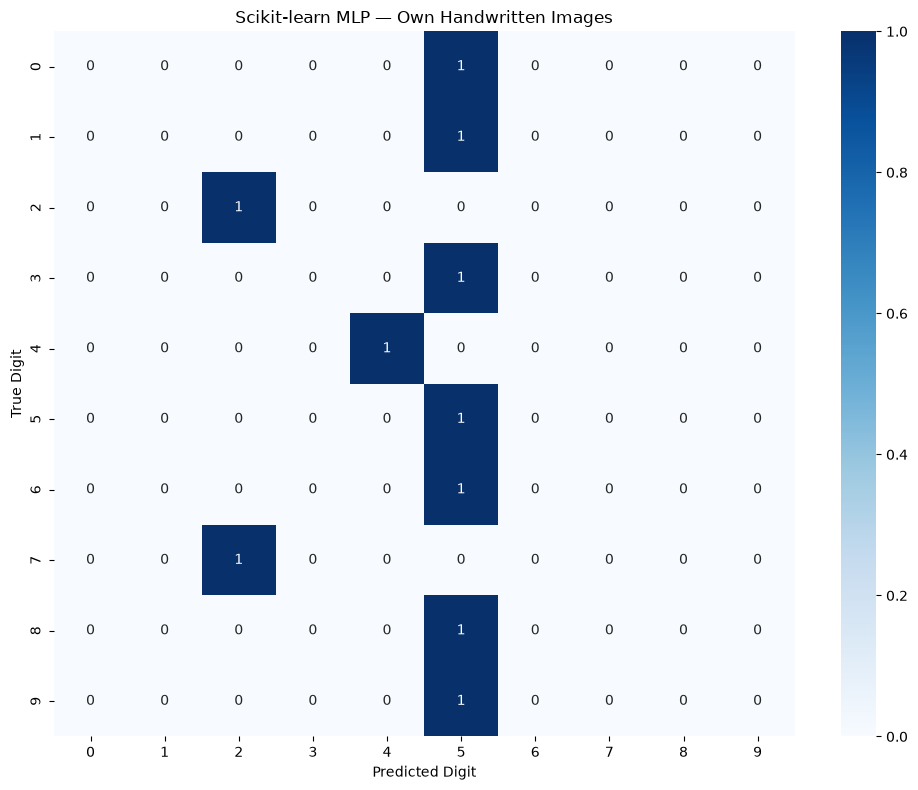

In [85]:
# Own Handwritten Image Inference
# Build and visualize the confusion matrix for the ten own handwritten digits.

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Define the ten MNIST digit classes
digit_classes = np.arange(10)

# Calculate the confusion matrix
own_cm = confusion_matrix(
    own_true_labels,
    own_predictions,
    labels=digit_classes
)

# Create a labeled DataFrame for easier interpretation
own_cm_df = pd.DataFrame(
    own_cm,
    index=digit_classes,
    columns=digit_classes
)

own_cm_df.index.name = "True Digit"
own_cm_df.columns.name = "Predicted Digit"

print("Scikit-learn MLP — Own Handwritten Image Confusion Matrix")
print(own_cm_df)

# Plot the confusion matrix
plt.figure(figsize=(10, 8))

sns.heatmap(
    own_cm_df,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted Digit")
plt.ylabel("True Digit")
plt.title("Scikit-learn MLP — Own Handwritten Images")
plt.tight_layout()
plt.show()

### Interpretation

The Scikit-learn MLP was applied to ten independently created handwritten digit images after preprocessing them into the same 28×28 grayscale format used by the MNIST-based model.

The model correctly classified 3 of the 10 own handwritten images, corresponding to an accuracy of 30.00%. The correctly recognized digits were 2, 4, and 5. Several of the other digits were incorrectly classified as 5, indicating that the model had difficulty generalizing from the MNIST image distribution to the independently created handwriting.

This result demonstrates that the high performance obtained on the MNIST test set does not necessarily transfer to images generated through a different process. Differences in handwriting style, stroke shape, thickness, positioning, and image characteristics can substantially affect the predictions of a model trained exclusively on MNIST.

The probability plots provide an additional view of the model's predictions and show the probability distribution assigned to each of the ten possible digit classes for every own handwritten image.
